In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

file_path = r"C:\Users\ofek3\Source\02_Idea_1973_Code\01_Sourse_Idea\data\nberces5818v1_n2012.csv"
df = pd.read_csv(file_path)

In [25]:
# --- Data setup: Create real value variables (VADD) ---
# 1. Create real variables - remove inflation effects
# Divide by energy price index - this shows actual energy amount used
df['real_energy'] = df['energy'] / df['pien']

# Use VADD (value added) and adjust with PISHIP (output price index)
# Why: VADD shows real industry growth without raw material noise
df['real_vadd'] = df['vadd'] / df['piship']

df['log_vadd'] = np.log(df['real_vadd'])
# 2. Calculate energy intensity compared to value added
# This shows how much energy was needed to create one unit of output
df['real_energy_intensity'] = df['real_energy'] / df['real_vadd']

print(f"Final table size: {df.shape} updated with VADD")
df[['year', 'naics', 'vadd', 'real_energy_intensity', 'real_vadd']].head()


Final table size: (22204, 28) updated with VADD


,year,naics,vadd,real_energy_intensity,real_vadd
0,1958,311111,266.9,0.080038,753.954798
1,1959,311111,268.7,0.085969,778.840582
2,1960,311111,269.9,0.072514,985.036536
3,1961,311111,287.8,0.075400,1054.212447
4,1962,311111,294.5,0.079831,1063.176857


In [26]:
# Check data quality: count missing values
missing_count = df['real_energy_intensity'].isnull().sum()
missing_count


np.int64(117)

In [27]:
# 1. Remove rows with missing data
df_clean = df.dropna(subset=['real_energy_intensity', 'tfp5']).copy()

# 2. Filter years for analysis: before crisis, during crisis, and recovery (1958-2018)
df_final = df_clean[(df_clean['year'] >= 1958) & (df_clean['year'] <= 2018)]

# Check how much data we have left for the final dataset
df_final.shape


(21359, 28)

In [28]:
# --- Classify industries and calculate basic statistics ---
# 1. Group industries by energy intensity into thirds (Terciles) using 1958-1972 data
# We define each industry's status in the 4 years before the crisis started

# Get data from pre-crisis period (1958-1972)
df_1958_1972 = df_final[(df_final['year'] <= 1972) & (df_final['year'] >= 1958)].copy()
mean_energy = df_1958_1972.groupby('naics')['real_energy_intensity'].mean()
energy_thresholds = mean_energy.quantile([0.33, 0.66])

# Function to classify each industry as Low, Medium, or High
def classify_energy(val):
    if val <= energy_thresholds[0.33]: return 'Low Energy'
    elif val <= energy_thresholds[0.66]: return 'Medium Energy'
    else: return 'High Energy'

# Create classification and apply to full dataset
energy_map = mean_energy.apply(classify_energy)
df_final['group_name'] = df_final['naics'].map(energy_map)

# Create helper variables for regression (0 or 1)
df_final['is_high_energy'] = (df_final['group_name'] == 'High Energy').astype(int)
df_final['post_1973'] = (df_final['year'] >= 1973).astype(int)
df_final['is_low_energy'] = (df_final['group_name'] == 'Low Energy').astype(int)

# 2. Classify industries by size (avg employees before crisis)
industry_size = df_final[df_final['year'] < 1972].groupby('naics')['emp'].mean()
size_thresholds = industry_size.quantile([0.33, 0.66])

def classify_size(emp_avg):
    if emp_avg <= size_thresholds[0.33]: return 'Small Industry'
    elif emp_avg <= size_thresholds[0.66]: return 'Medium Industry'
    else: return 'Large Industry'

# Apply size classification
df_final['industry_size_cat'] = df_final['naics'].map(industry_size.apply(classify_size))

# 3. Create descriptive statistics table
# Calculate mean and standard deviation for main variables by group
desc_stats = df_final.groupby('group_name')[['tfp5', 'real_energy_intensity', 'emp']].agg(['mean', 'std']).round(3)

print("--- SUMMARY STATISTICS BY ENERGY GROUP (TERCILES) ---")
display(desc_stats) 

# 4. Check industry distribution
print("\n--- INDUSTRY SIZE DISTRIBUTION ---")
print(df_final.drop_duplicates('naics')['industry_size_cat'].value_counts())

print("\n--- ENERGY GROUP DISTRIBUTION ---")
print(df_final.drop_duplicates('naics')['group_name'].value_counts())


--- SUMMARY STATISTICS BY ENERGY GROUP (TERCILES) ---


tfp5        real_energy_intensity            emp        
                mean    std                  mean    std    mean     std
group_name                                                              
High Energy    0.852  0.261                 0.344  3.501  39.990  56.246
Low Energy     1.048  0.241                 0.018  0.009  51.013  65.309
Medium Energy  0.953  0.213                 0.030  0.013  39.999  41.568


--- INDUSTRY SIZE DISTRIBUTION ---
industry_size_cat
Large Industry     123
Small Industry     119
Medium Industry    119
Name: count, dtype: int64

--- ENERGY GROUP DISTRIBUTION ---
group_name
High Energy      123
Low Energy       119
Medium Energy    119
Name: count, dtype: int64


In [29]:
# --- Create tables showing industry classification ---

# 1. Get a unique list of industries and their groups
# Take one row per industry (using 1972 data) to avoid duplicates
industry_list = df_final[df_final['year'] == 1972][['naics', 'group_name', 'real_energy_intensity']].copy()
industry_list = industry_list.sort_values(['group_name', 'real_energy_intensity'], ascending=[True, False])

# 2. Create "example table" - shows top 5 most representative industries in each group
def get_top_examples(group_df):
    return group_df.head(5)['naics'].tolist()

sample_table = industry_list.groupby('group_name').apply(get_top_examples).reset_index()
sample_table.columns = ['Energy Group', 'Top 5 Representative Industries (NAICS Codes)']

print("--- Example table: Most extreme industries in each group ---")
display(sample_table)

# 3. Save full list to CSV (for appendix in your paper)
# You can open this, manually add industry names, and paste in your work
industry_list.to_csv('industry_classification_list.csv', index=False)
print("\nFull list saved to: 'industry_classification_list.csv'")

# 4. Sanity check - verify the classification makes sense
print("\n--- Verification (Face Validity) ---")
print("Industry with highest energy intensity (High Energy):")
top_industry = industry_list.iloc[0]
print(f"NAICS: {top_industry['naics']}, Intensity: {top_industry['real_energy_intensity']:.4f}")

print("\nIndustry with lowest energy intensity (Low Energy):")
bottom_industry = industry_list.iloc[-1]
print(f"NAICS: {bottom_industry['naics']}, Intensity: {bottom_industry['real_energy_intensity']:.4f}")


--- Example table: Most extreme industries in each group ---


C:\Users\ofek3\AppData\Local\Temp\ipykernel_5416\1202790218.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_table = industry_list.groupby('group_name').apply(get_top_examples).reset_index()


,Energy Group,Top 5 Representative Industries (NAICS Codes)
0,High Energy,"[334111, 334413, 334112, 334118, 311213]"
1,Low Energy,"[336330, 336340, 336350, 336390, 316992]"
2,Medium Energy,"[332812, 331420, 311612, 331222, 311423]"



Full list saved to: 'industry_classification_list.csv'

--- Verification (Face Validity) ---
Industry with highest energy intensity (High Energy):
NAICS: 334111, Intensity: 64.4488

Industry with lowest energy intensity (Low Energy):
NAICS: 325413, Intensity: 0.0186


In [30]:
# --- Compare different time periods (Structural Break Analysis) ---

# Calculate growth variables for graphs
df_final = df_final.sort_values(['naics', 'year'])
df_final['vadd_growth'] = df_final.groupby('naics')['real_vadd'].pct_change() * 100

# Define time periods
# 1973 is the cutoff point for the crisis
# Pre-Crisis: until and including 1973 
# Post-Crisis: 1974 and later
df_final['period'] = np.where(df_final['year'] <= 1973, 'Pre-Crisis (1958-1973)', 'Post-Crisis (1974-2018)')

# Pick variables we want to analyze
# Productivity (TFP), energy efficiency (Intensity), and growth rate
cols_to_analyze = ['tfp5', 'real_energy_intensity', 'vadd_growth']

# Calculate descriptive stats (mean and std) for each period and group
period_stats = df_final.groupby(['group_name', 'period'])[cols_to_analyze].agg(['mean', 'std'])

# Calculate the "structural break" - how much did the average change between periods
# Pre-Crisis: before 1973 averages
# Post-Crisis: after 1973 averages
pre_means = df_final[df_final['period'] == 'Pre-Crisis (1958-1973)'].groupby('group_name')[cols_to_analyze].mean()
post_means = df_final[df_final['period'] == 'Post-Crisis (1974-2018)'].groupby('group_name')[cols_to_analyze].mean()

change_table = post_means - pre_means

print("=" * 80)
print("STRUCTURAL BREAK TABLE: PRE vs. POST CRISIS")
print("=" * 80)
print("Table shows: average (mean) and standard deviation (std) for each period")
display(period_stats.round(3))

print("\n" + "=" * 80)
print("THE SHIFT: CHANGE IN AVERAGES (POST - PRE)")
print("=" * 80)
print("Negative Energy Intensity change = Good (industries became more efficient)")
display(change_table.round(4))


STRUCTURAL BREAK TABLE: PRE vs. POST CRISIS
Table shows: average (mean) and standard deviation (std) for each period


tfp5        real_energy_intensity  \
                                        mean    std                  mean   
group_name    period                                                        
High Energy   Post-Crisis (1974-2018)  0.896  0.235                 0.157   
              Pre-Crisis (1958-1973)   0.732  0.289                 0.845   
Low Energy    Post-Crisis (1974-2018)  1.031  0.222                 0.019   
              Pre-Crisis (1958-1973)   1.091  0.281                 0.016   
Medium Energy Post-Crisis (1974-2018)  0.982  0.179                 0.029   
              Pre-Crisis (1958-1973)   0.873  0.269                 0.032   

                                             vadd_growth          
                                         std        mean     std  
group_name    period                                              
High Energy   Post-Crisis (1974-2018)  0.892       2.812  17.221  
              Pre-Crisis (1958-1973)   6.538       6.613  11.856  
Low Energy    Post-Crisis (1974-2018)  0.010       1.356  14.451  
              Pre-Crisis (1958-1973)   0.006       5.527  11.587  
Medium Energy Post-Crisis (1974-2018)  0.014       1.894  13.060  
              Pre-Crisis (1958-1973)   0.009       6.638  13.166


THE SHIFT: CHANGE IN AVERAGES (POST - PRE)
Negative Energy Intensity change = Good (industries became more efficient)


,tfp5,real_energy_intensity,vadd_growth
group_name,,,
High Energy,0.1645,-0.6877,-3.8007
Low Energy,-0.0597,0.0031,-4.1711
Medium Energy,0.1092,-0.0027,-4.7438


In [31]:
# --- Set up chart styling (global settings for all graphs) ---

# Use clean theme
plt.style.use('seaborn-v0_8-whitegrid')

# Custom settings for readable, professional-looking graphs
params = {
    # Fonts
    'font.family': 'sans-serif', 
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    
    'axes.labelsize': 14,          # Size of X and Y axis labels
    'axes.titlesize': 16,          # Size of main title
    'xtick.labelsize': 12,         # Size of numbers on axis
    'ytick.labelsize': 12,
    'legend.fontsize': 12,         # Size of legend text
    
    # Lines and quality
    'lines.linewidth': 2.5,        # Line thickness in graphs
    'figure.dpi': 120,             # High resolution
    'axes.grid': True,             # Show grid lines
    'grid.alpha': 0.3              # Make grid transparent
}

# Apply settings to all graphs in this notebook
plt.rcParams.update(params)


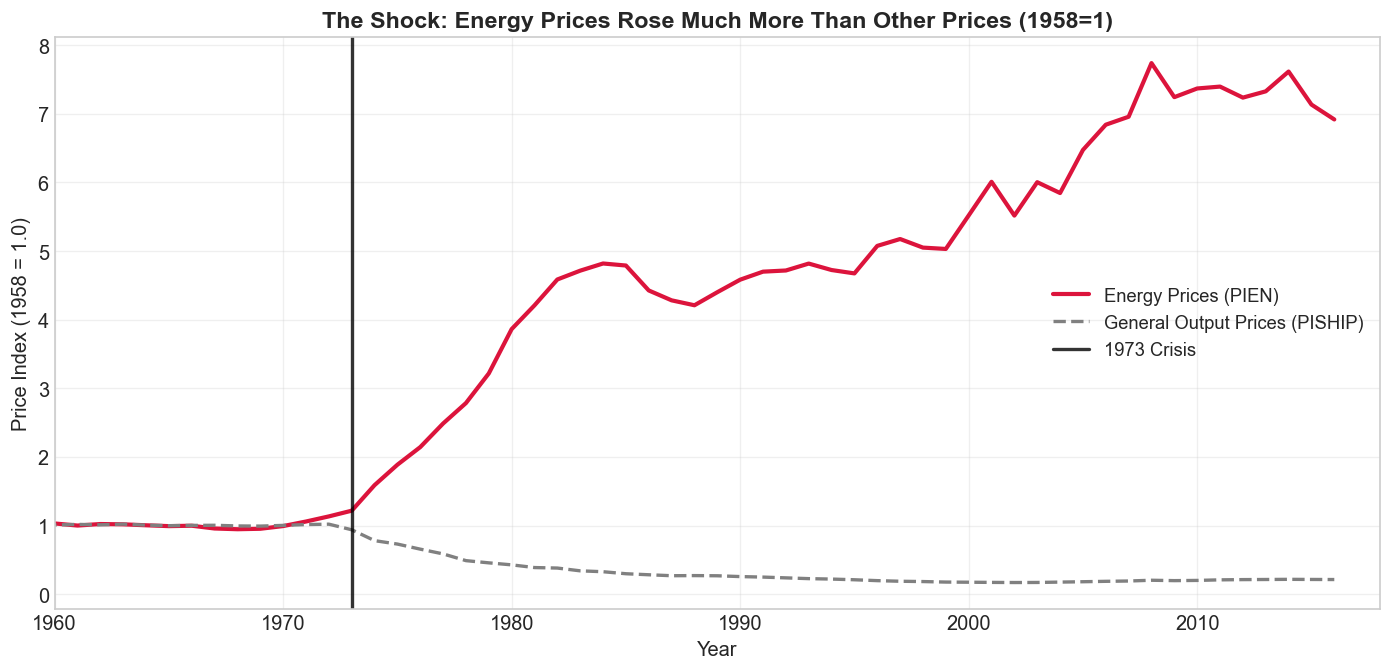

In [32]:
# --- Graph 1: Energy Price Shock (Energy prices vs Output prices) ---

plt.figure(figsize=(12, 6))

# Calculate yearly average of price indices
price_trends = df_final.groupby('year')[['pien', 'piship']].mean()

# Normalize so 1958 = 1.0 for easy comparison
base_year_val = price_trends.loc[1958]
normalized_prices = price_trends / base_year_val

# Draw the lines
plt.plot(normalized_prices.index, normalized_prices['pien'], label='Energy Prices (PIEN)', color='crimson', linewidth=2.5)
plt.plot(normalized_prices.index, normalized_prices['piship'], label='General Output Prices (PISHIP)', color='grey', linestyle='--', linewidth=2)

# Add formatting
plt.axvline(x=1973, color='black', linestyle='-', alpha=0.8, label='1973 Crisis', linewidth=2)
plt.title('The Shock: Energy Prices Rose Much More Than Other Prices (1958=1)', fontweight='bold', fontsize=14)
plt.ylabel('Price Index (1958 = 1.0)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(1960, 2018) # Focus on relevant years

plt.tight_layout()
plt.show()
# This graph shows that after 1973, energy prices "jumped" compared to other prices in the economy


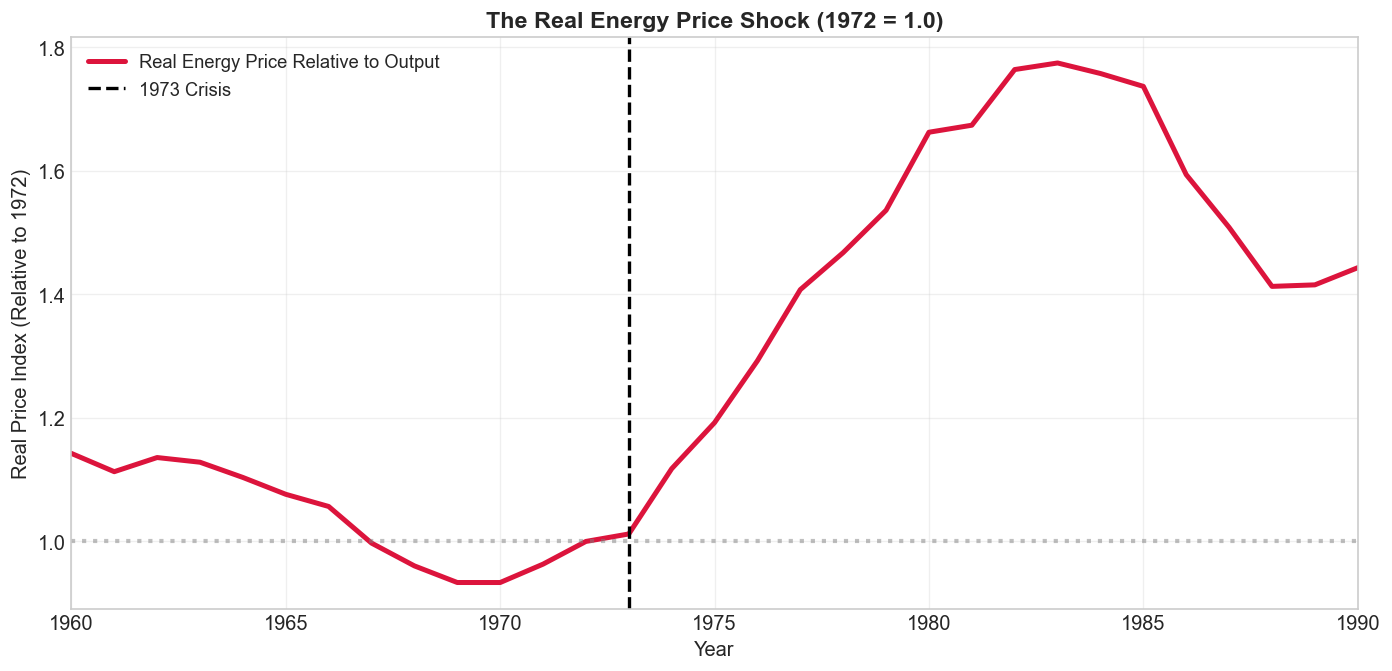

In [33]:
plt.figure(figsize=(12, 6))

# 1. Calculate real relative energy prices
# Divide energy price by output price to see if energy became more expensive "relative to other things"
df_final['relative_price'] = df_final['pien'] / df_final['piship']

# 2. Calculate yearly average
relative_trend = df_final.groupby('year')['relative_price'].mean()

# 3. Normalize to 1972 (so we can say "X times more expensive than before crisis")
base_year_val = relative_trend.loc[1972]
normalized_relative = relative_trend / base_year_val

# Draw the graph (clean, single line)
plt.plot(normalized_relative.index, normalized_relative.values, 
         color='crimson', linewidth=3, label='Real Energy Price Relative to Output')

# Formatting
plt.axvline(x=1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis')
plt.axhline(y=1, color='grey', linestyle=':', alpha=0.5) # Reference line

plt.title('The Real Energy Price Shock (1972 = 1.0)', fontweight='bold', fontsize=14)
plt.ylabel('Real Price Index (Relative to 1972)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(1960, 1990) 

plt.tight_layout()
plt.show()

# This graph clearly shows the "shock": prices were stable until 1973, then jumped 2-3x higher
# This price increase is what pushed companies to become more energy-efficient

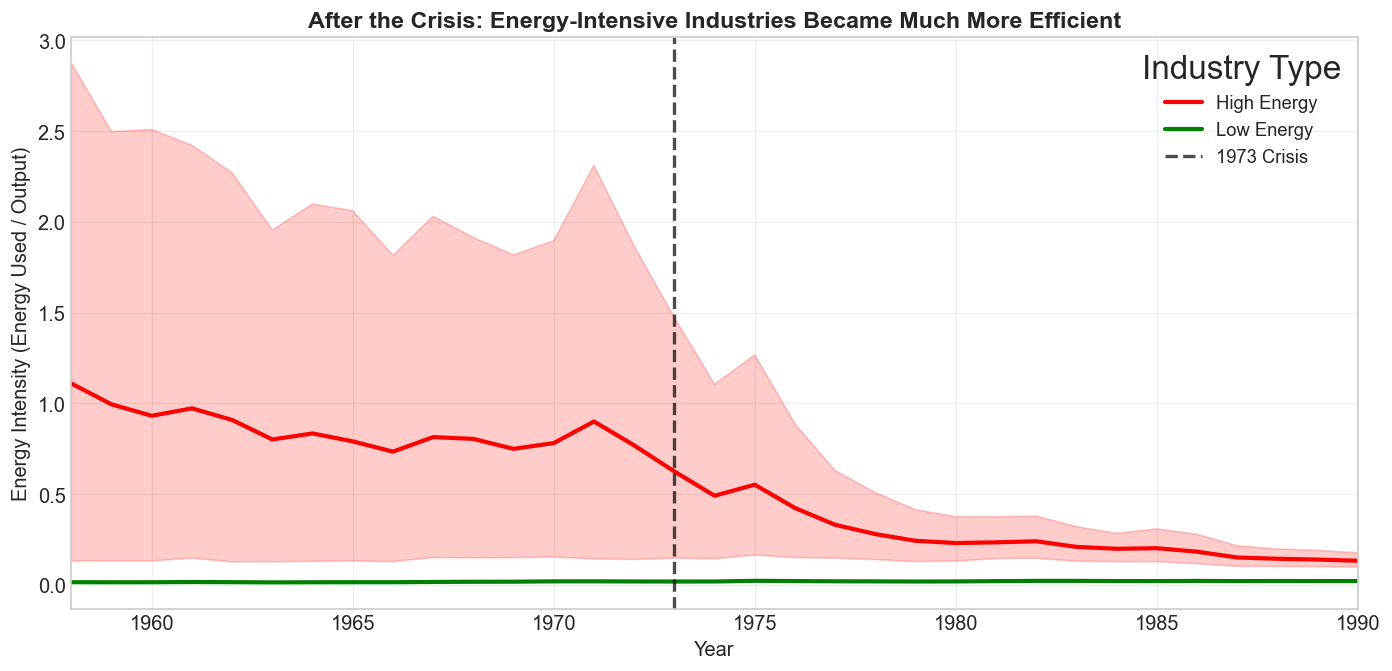

In [34]:
# --- Graph 2: The Divergence (Energy intensity over time by group) ---

plt.figure(figsize=(12, 6))

# Only show the extreme groups (High and Low) to keep the graph clean
subset = df_final[df_final['group_name'].isin(['High Energy', 'Low Energy'])]

# Create line plot with automatic confidence bands
sns.lineplot(data=subset, x='year', y='real_energy_intensity', hue='group_name', 
             palette={'High Energy': 'red', 'Low Energy': 'green'}, linewidth=2.5)

# Formatting
plt.axvline(x=1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis', alpha=0.7)
plt.title('After the Crisis: Energy-Intensive Industries Became Much More Efficient', fontweight='bold', fontsize=14)
plt.ylabel('Energy Intensity (Energy Used / Output)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xlim(1958, 1990) # Focus on key period
plt.legend(title='Industry Type', fontsize=11)

plt.tight_layout()
plt.show()

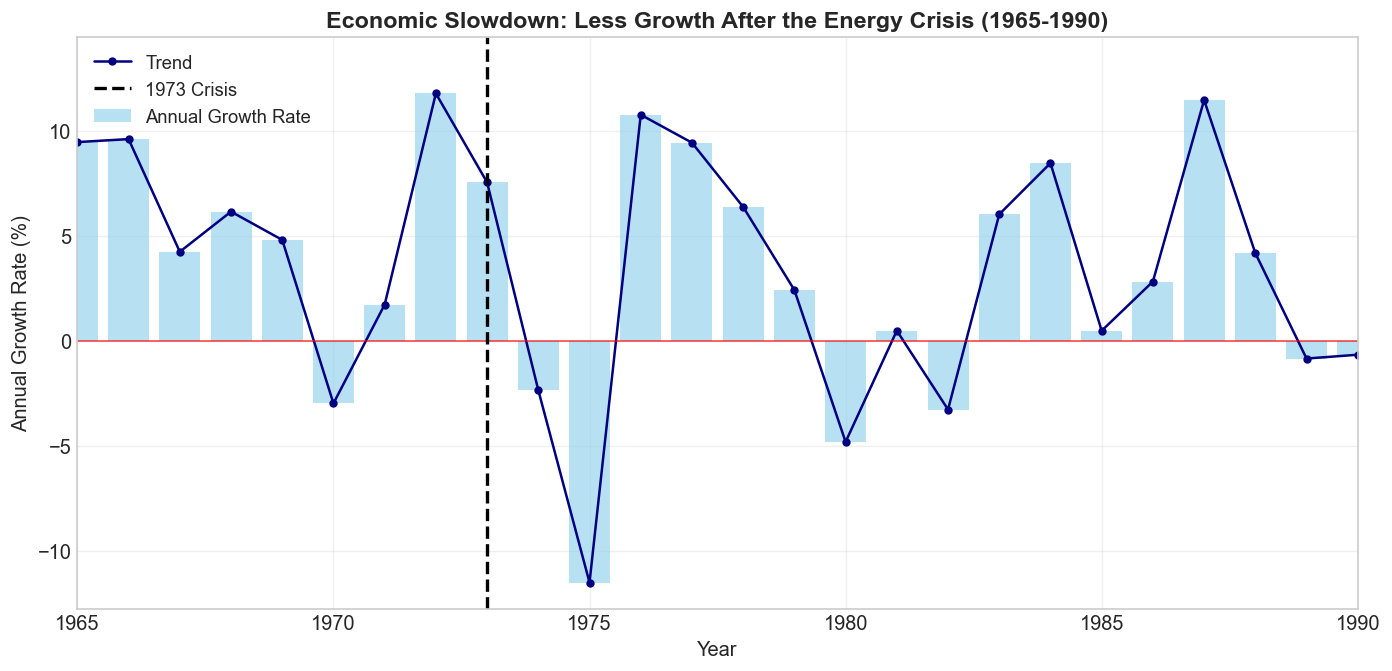

In [35]:
# --- Graph 3: Stagflation (Growth rates show the crisis impact) ---

plt.figure(figsize=(12, 6))

# Calculate average yearly growth for all industries
avg_growth = df_final.groupby('year')['vadd_growth'].mean()

# Create bar chart with trend line
plt.bar(avg_growth.index, avg_growth.values, color='skyblue', alpha=0.6, label='Annual Growth Rate')
plt.plot(avg_growth.index, avg_growth.values, color='navy', marker='o', markersize=4, linewidth=1.5, label='Trend')

# Add reference line at 0 (no growth)
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)
plt.axvline(x=1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis')

# Formatting
plt.title('Economic Slowdown: Less Growth After the Energy Crisis (1965-1990)', fontweight='bold', fontsize=14)
plt.ylabel('Annual Growth Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xlim(1965, 1990) # Zoom in on crisis period
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# לשקול להוסיף גרף זהה לאנרגיות גבוהה ונמוכה אחרי ה matching
# Below 0 line = recession; high-energy industries were hit hardest

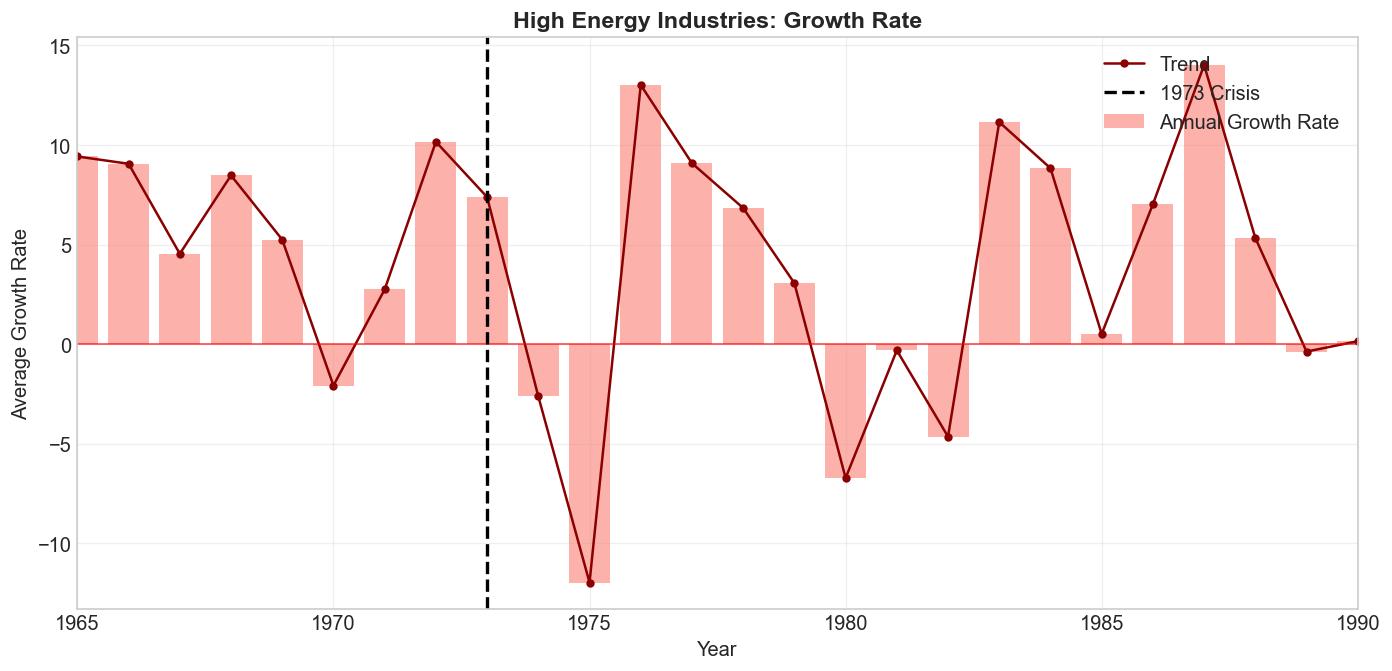

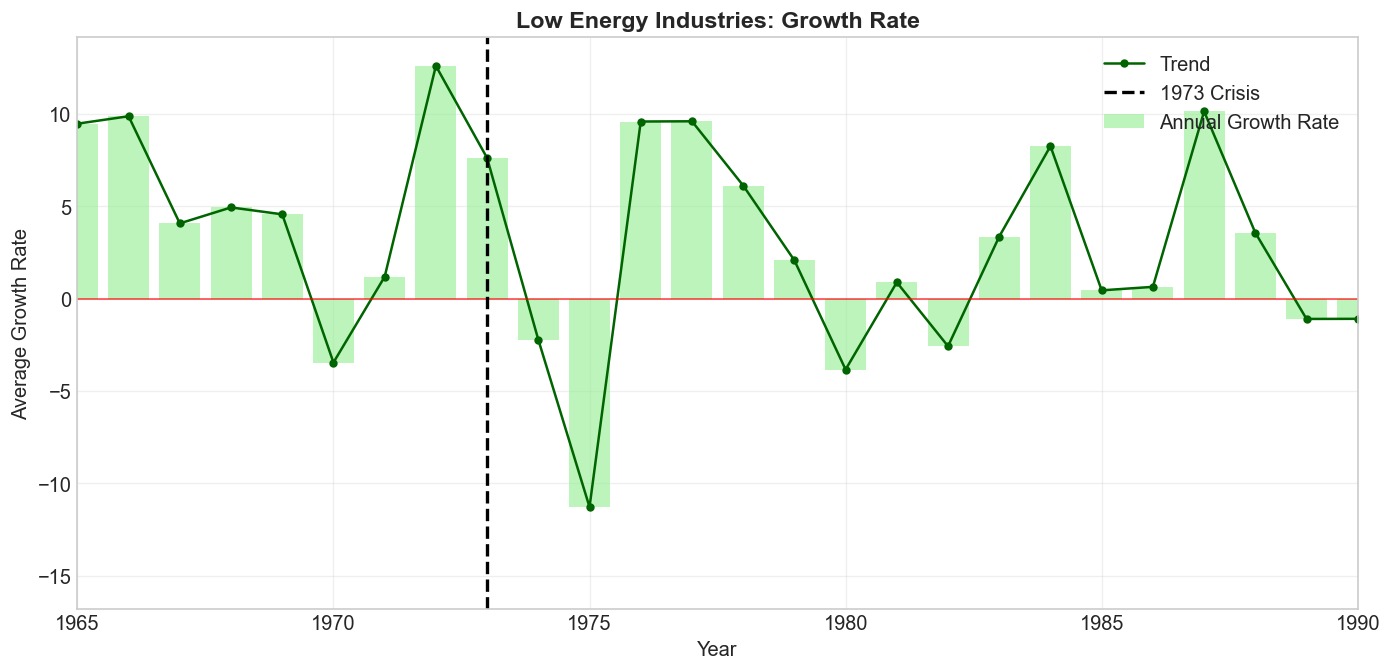

In [36]:
# A function to draw the growth graph so I don't have to write it three times
def plot_growth_graph(data, title_text, bar_color, line_color):
    plt.figure(figsize=(12, 6))

    # Get the average growth for each year
    avg_growth = data.groupby('year')['vadd_growth'].mean()

    # Create the bars and the line on top
    plt.bar(avg_growth.index, avg_growth.values, color=bar_color, alpha=0.6, label='Annual Growth Rate')
    plt.plot(avg_growth.index, avg_growth.values, color=line_color, marker='o', markersize=4, linewidth=1.5, label='Trend')

    # Lines to show zero growth and when the crisis started
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)
    plt.axvline(x=1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis')

    # Setting up the labels and titles
    plt.title(title_text, fontweight='bold', fontsize=14)
    plt.ylabel('Average Growth Rate', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.xlim(1965, 1990) # Focused on the years around the crisis
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Graph for industries that used a lot of energy before the crisis
high_energy_data = df_final[df_final['is_high_energy'] == 1]
plot_growth_graph(
    data=high_energy_data, 
    title_text='High Energy Industries: Growth Rate', 
    bar_color='salmon', 
    line_color='darkred'
)

# Graph for industries that used very little energy
low_energy_data = df_final[df_final['is_high_energy'] == 0]
plot_growth_graph(
    data=low_energy_data, 
    title_text='Low Energy Industries: Growth Rate', 
    bar_color='lightgreen', 
    line_color='darkgreen'
)

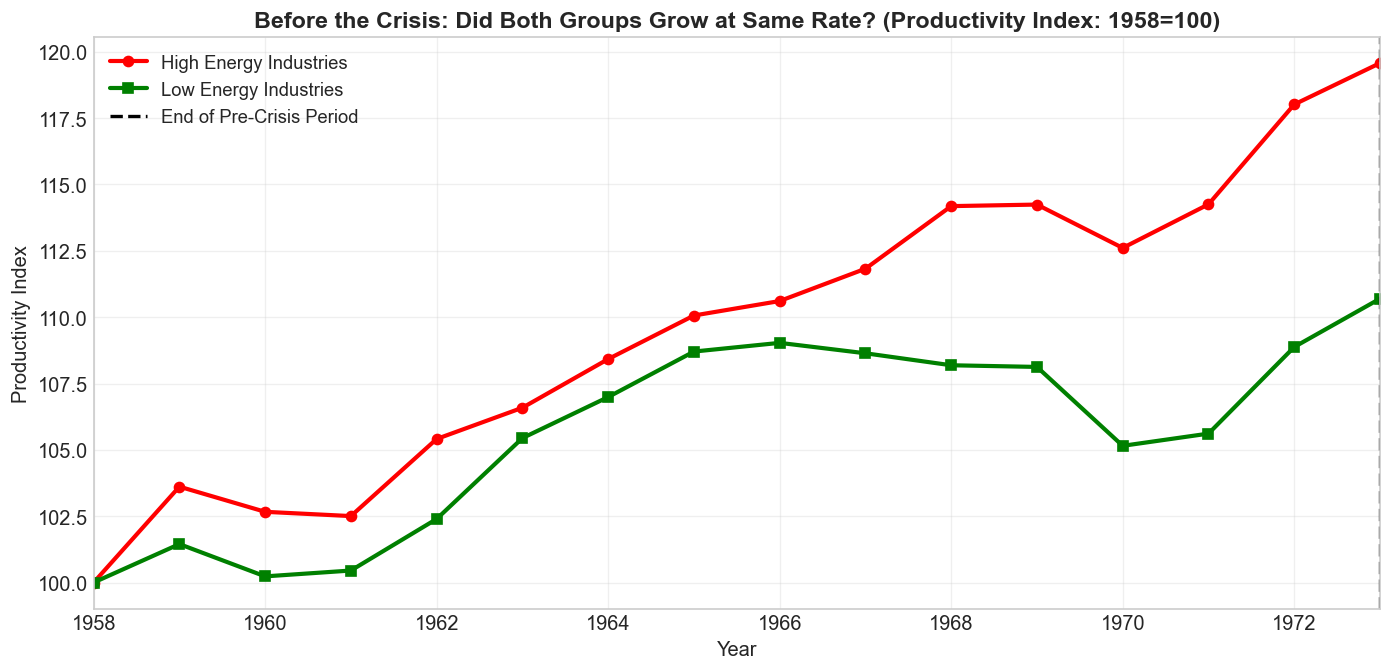

In [37]:
# --- Graph 4: Parallel Trends Test (TFP before the crisis) ---

plt.figure(figsize=(12, 6))

# Get data from pre-crisis only, for extreme groups only
pre_crisis = df_final[(df_final['year'] <= 1973) & (df_final['group_name'].isin(['High Energy', 'Low Energy']))]

# Calculate yearly average TFP for each group
tfp_trends = pre_crisis.groupby(['year', 'group_name'])['tfp5'].mean().unstack()

# Normalize to 1958=100 so we can compare growth rates, not absolute levels
tfp_normalized = tfp_trends / tfp_trends.loc[1958] * 100

# Draw both groups
plt.plot(tfp_normalized.index, tfp_normalized['High Energy'], label='High Energy Industries', color='red', marker='o', linewidth=2.5)
plt.plot(tfp_normalized.index, tfp_normalized['Low Energy'], label='Low Energy Industries', color='green', marker='s', linewidth=2.5)

# Formatting
plt.axvline(x=1973, color='black', linestyle='--', linewidth=2, label='End of Pre-Crisis Period')
plt.title('Before the Crisis: Did Both Groups Grow at Same Rate? (Productivity Index: 1958=100)', fontweight='bold', fontsize=14)
plt.ylabel('Productivity Index', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(1958, 1973)

plt.tight_layout()
plt.show()
# If lines are parallel before 1973, it supports our research design 

C:\Users\ofek3\AppData\Local\Temp\ipykernel_5416\2618182827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ofek3\AppData\Local\Temp\ipykernel_5416\2618182827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ofek3\AppData\Local\Temp\ipykernel_5416\2618182827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ofek3\AppData\Local\Temp\ipykernel_5416\2618182827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

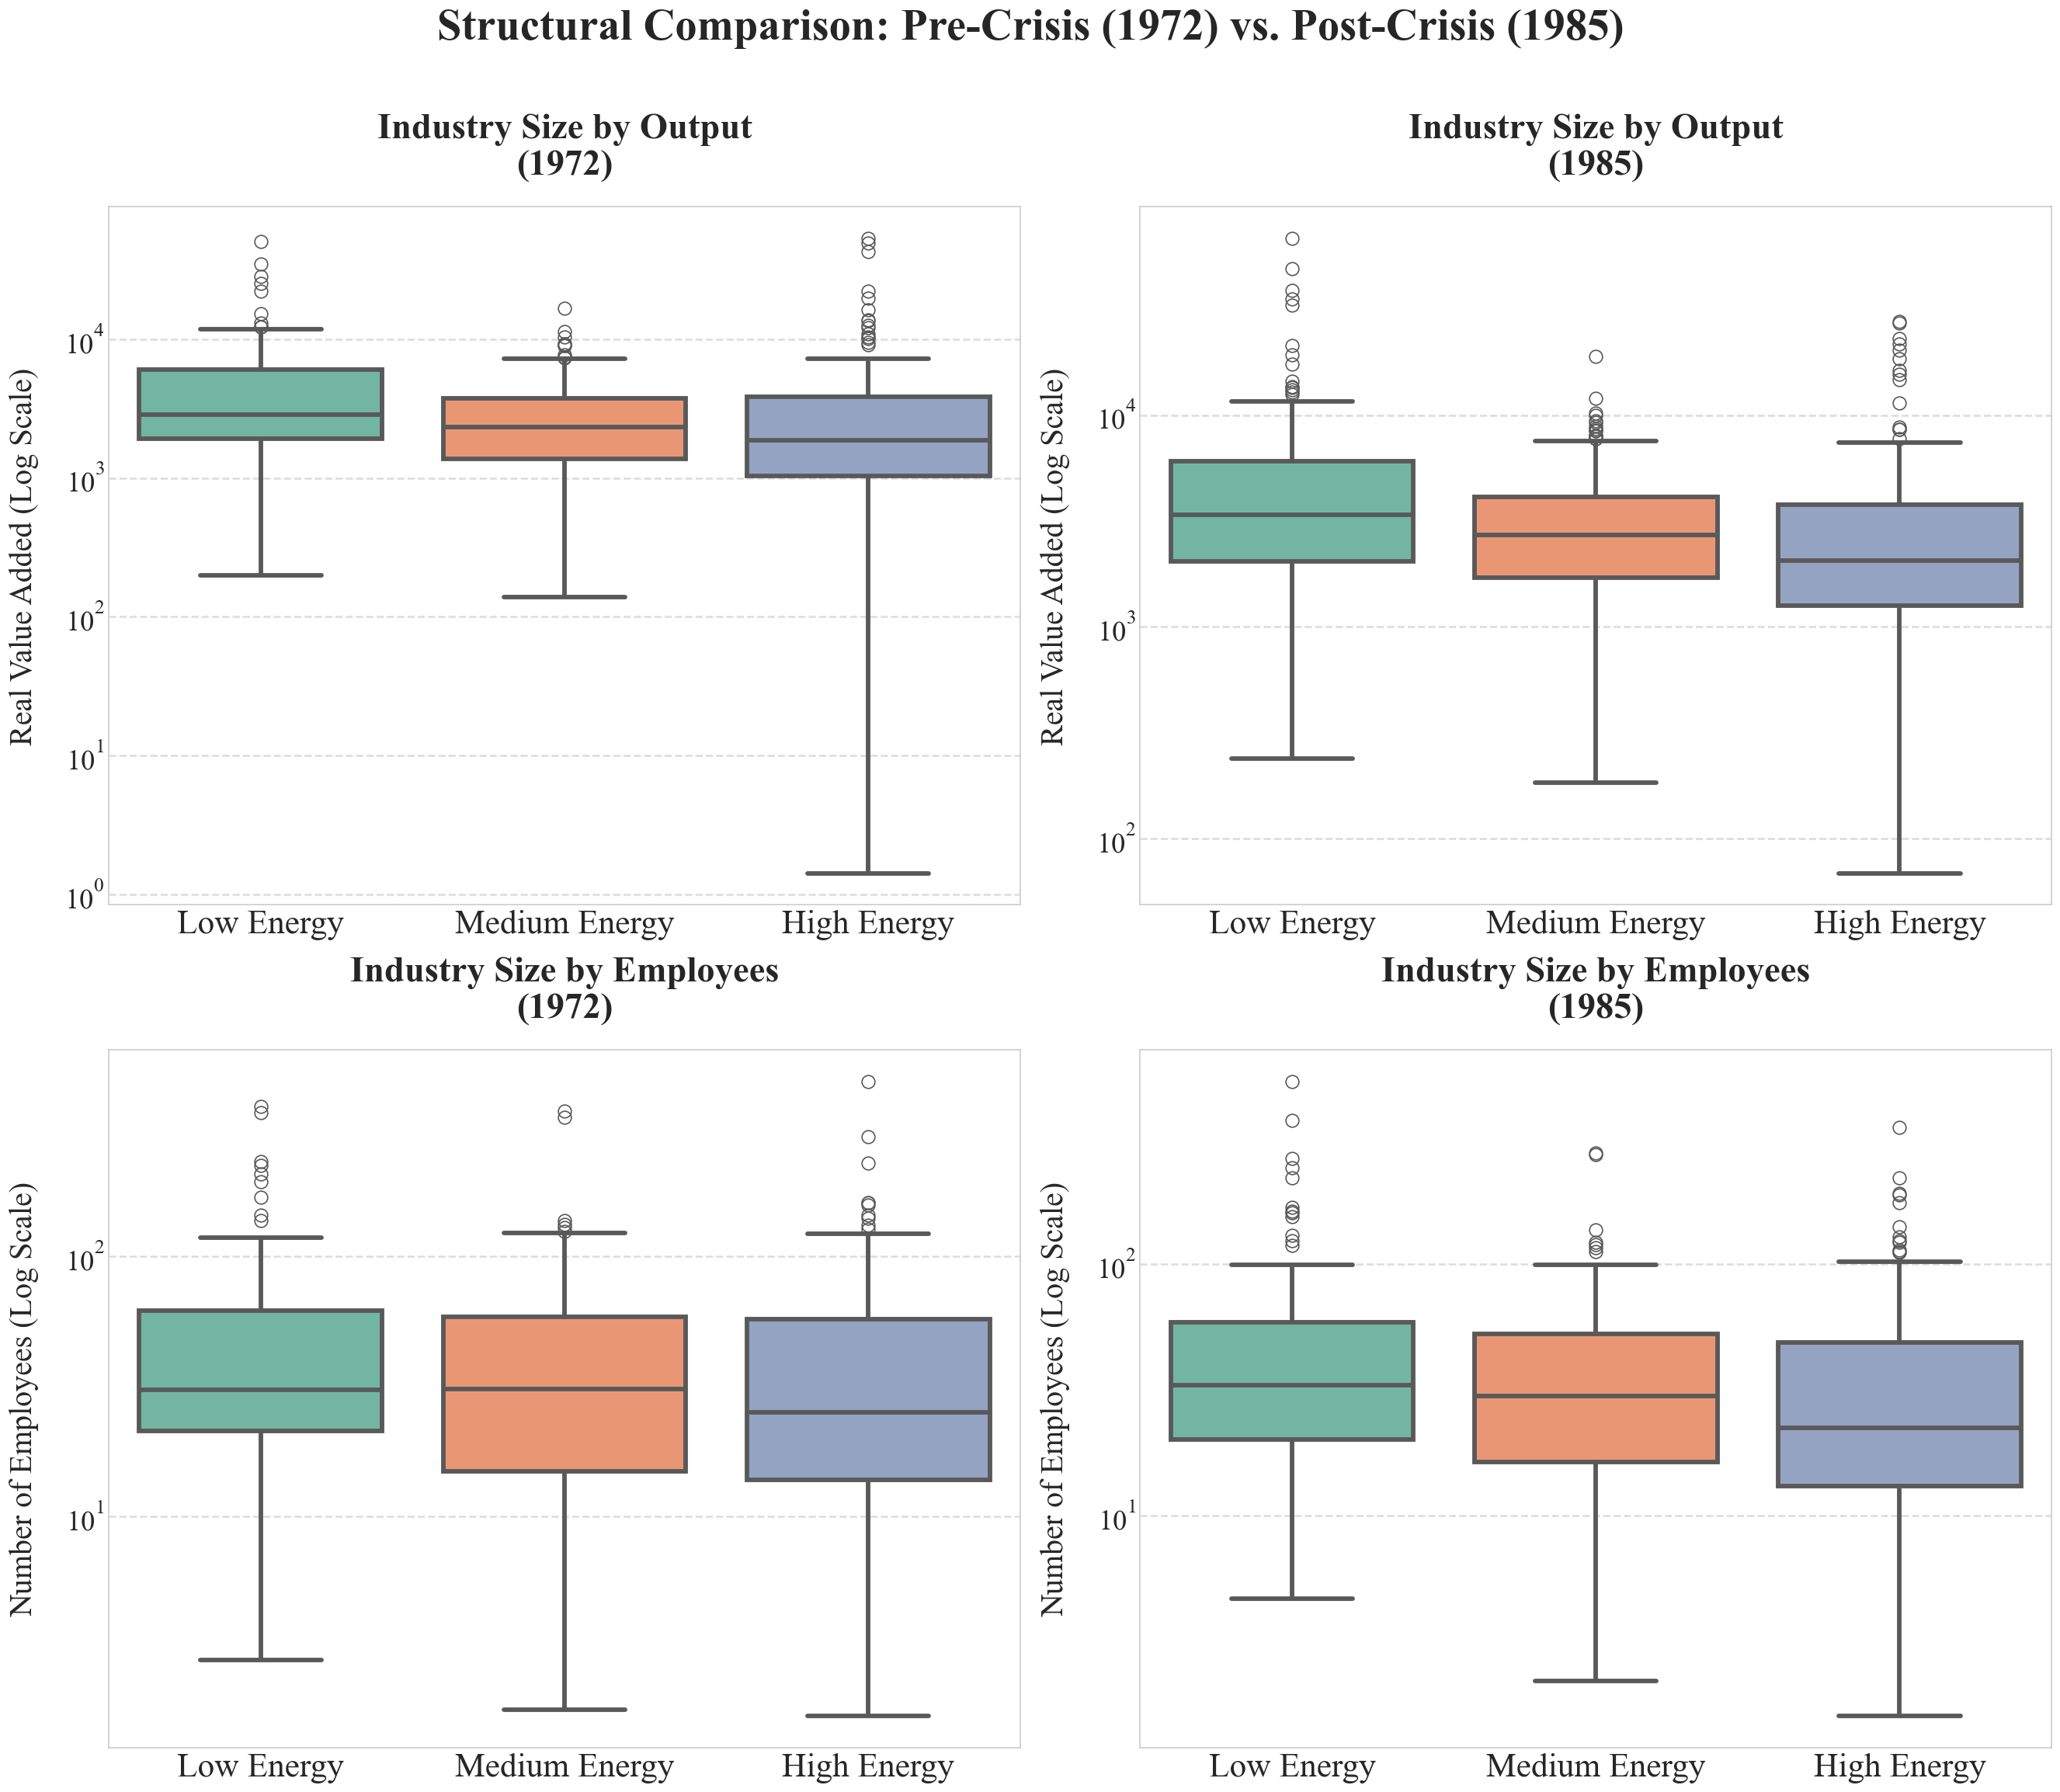

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת פרמטרים גלובליים כולל פונט Times New Roman
plt.rcParams.update({
    'font.family': 'serif',        # הגדרת משפחת הגופנים לסריף
    'font.serif': ['Times New Roman'], # בחירת Times New Roman כפונט הסריפי
    'mathtext.fontset': 'stix',    # התאמת פונט הנוסחאות (אם יהיו) למראה דומה
    'font.size': 20,               # פונט בסיסי גדול מאוד
    'axes.titlesize': 28,          # כותרות של תתי-גרפים
    'axes.labelsize': 24,          # תוויות צירים (Y)
    'xtick.labelsize': 26,         # הגדלה ספציפית לתוויות הקבוצות
    'ytick.labelsize': 22,         # מספרים על ציר ה-Y
    'figure.titlesize': 34         # הכותרת הראשית של כל הגרף
})

# שאר הקוד שלך ללא שינוי...
years_to_compare = [1972, 1985]
metrics = [
    ('real_vadd', 'Real Value Added (Log Scale)', 'Industry Size by Output'),
    ('emp', 'Number of Employees (Log Scale)', 'Industry Size by Employees')
]

fig, axes = plt.subplots(2, 2, figsize=(22, 18), constrained_layout=True)

for row, (metric_col, ylabel, title_prefix) in enumerate(metrics):
    for col, year in enumerate(years_to_compare):
        ax = axes[row, col]
        
        # סינון נתונים (בהנחה ש-df_final קיים)
        year_data = df_final[df_final['year'] == year]
        
        sns.boxplot(
            data=year_data, 
            x='group_name', 
            y=metric_col, 
            order=['Low Energy', 'Medium Energy', 'High Energy'], 
            ax=ax, 
            palette='Set2',
            linewidth=3.5,
            fliersize=10
        )
        
        ax.set_yscale('log')
        ax.set_title(f'{title_prefix}\n({year})', fontweight='bold', pad=25)
        ax.set_ylabel(ylabel, labelpad=20)
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.7, linewidth=1.5)

fig.suptitle('Structural Comparison: Pre-Crisis (1972) vs. Post-Crisis (1985)', 
             fontweight='bold', y=1.06)

plt.show()

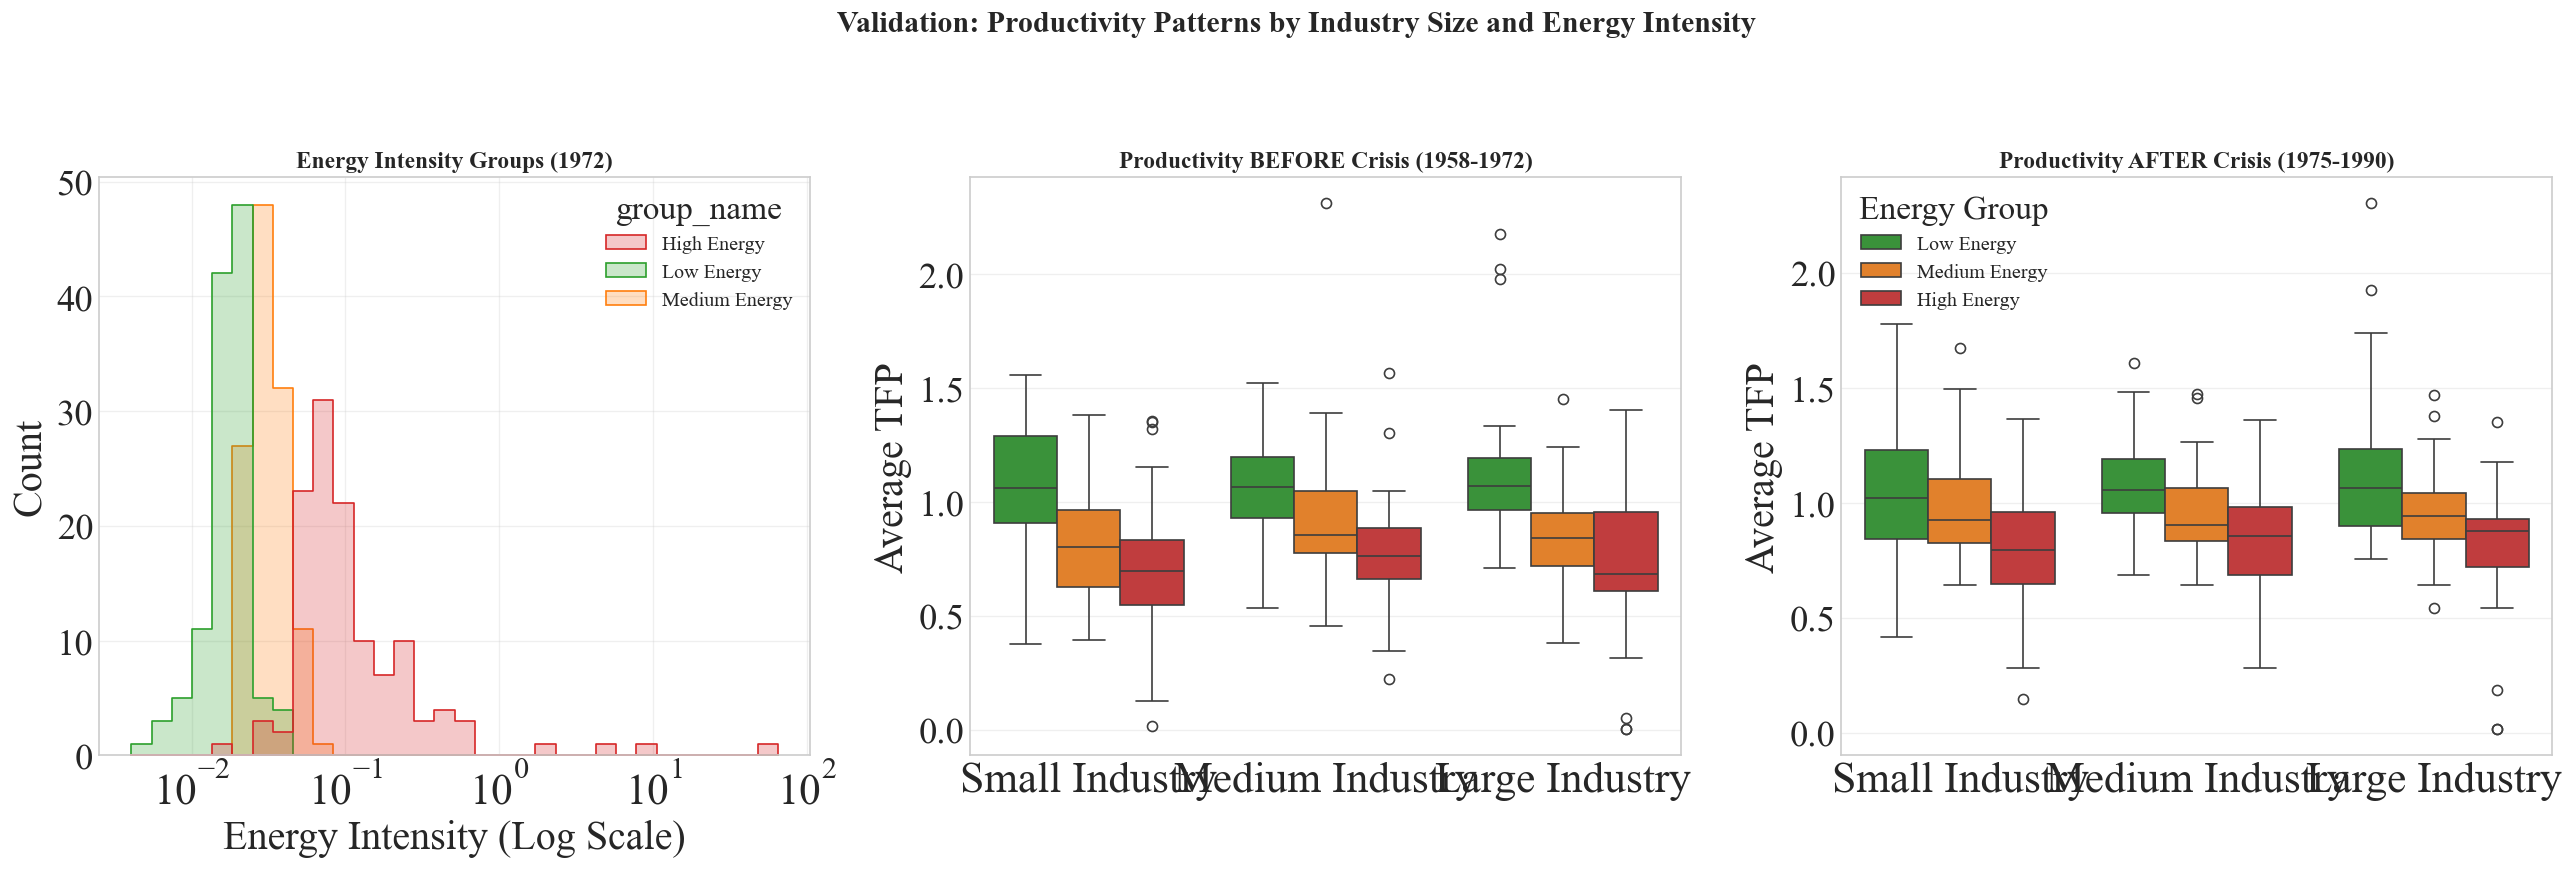

In [39]:
# 1. Prepare the data for Pre and Post crisis periods
pre_crisis_avg = df_final[(df_final['year'] >= 1958) & (df_final['year'] <= 1972)].copy()
post_crisis_avg = df_final[(df_final['year'] >= 1975) & (df_final['year'] <= 1990)].copy()

# Group by industry to get a single average per sector for each period
pre_summary = pre_crisis_avg.groupby(['naics', 'group_name', 'industry_size_cat'])['tfp5'].mean().reset_index()
post_summary = post_crisis_avg.groupby(['naics', 'group_name', 'industry_size_cat'])['tfp5'].mean().reset_index()

# Sort the size categories so they appear in order
size_order = ['Small Industry', 'Medium Industry', 'Large Industry']
color_palette = {'High Energy': '#d62728', 'Medium Energy': '#ff7f0e', 'Low Energy': '#2ca02c'}

# Create a figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Graph 1: Intensity Distribution (Verification) ---
sns.histplot(
    data=df_final[df_final['year'] == 1972], 
    x='real_energy_intensity', hue='group_name', 
    element="step", log_scale=True, ax=axes[0], palette=color_palette
)
axes[0].set_title('Energy Intensity Groups (1972)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Energy Intensity (Log Scale)')

# --- Graph 2: Productivity BEFORE Crisis (1958-1972) ---
sns.boxplot(
    data=pre_summary, x='industry_size_cat', y='tfp5', hue='group_name',
    order=size_order, hue_order=['Low Energy', 'Medium Energy', 'High Energy'],
    palette=color_palette, ax=axes[1]
)
axes[1].set_title('Productivity BEFORE Crisis (1958-1972)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Average TFP')
axes[1].set_xlabel('')
axes[1].get_legend().remove() # Clean up legend for middle plot

# --- Graph 3: Productivity AFTER Crisis (1975-1990) ---
sns.boxplot(
    data=post_summary, x='industry_size_cat', y='tfp5', hue='group_name',
    order=size_order, hue_order=['Low Energy', 'Medium Energy', 'High Energy'],
    palette=color_palette, ax=axes[2]
)
axes[2].set_title('Productivity AFTER Crisis (1975-1990)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Average TFP')
axes[2].set_xlabel('')
axes[2].legend(title='Energy Group')

# Final adjustments
plt.suptitle('Validation: Productivity Patterns by Industry Size and Energy Intensity', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

plt.show()

In [40]:
# Prepare comparison data for pre and post-crisis periods
period_comparison = []

# Period 1: Before the crisis (1965-1972)
pre_data = df_final[(df_final['year'] >= 1965) & (df_final['year'] <= 1972)].copy()
pre_means = pre_data.groupby(['naics', 'group_name'])['tfp5'].mean().reset_index()
pre_means['Period'] = 'Pre-Crisis Avg (1965-1972)'
period_comparison.append(pre_means)

# Period 2: After the crisis (1980-1990)
post_data = df_final[(df_final['year'] >= 1980) & (df_final['year'] <= 1990)].copy()
post_means = post_data.groupby(['naics', 'group_name'])['tfp5'].mean().reset_index()
post_means['Period'] = 'Post-Crisis Avg (1980-1990)'
period_comparison.append(post_means)

# Combine all data for visualization
viz_data = pd.concat(period_comparison)

# # 2. הציור: Boxplot שמשווה את ההתפלגויות
# plt.figure(figsize=(10, 6))

# # סדר הקבוצות בתרשים
# hue_order = ['Low Energy', 'Medium Energy', 'High Energy']
# palette = {'High Energy': 'red', 'Medium Energy': 'orange', 'Low Energy': 'green'}

# sns.boxplot(
#     data=viz_data, 
#     x='Period', 
#     y='tfp5', 
#     hue='group_name',
#     hue_order=hue_order,
#     palette=palette,
#     showmeans=True, # מוסיף נקודה שמראה את הממוצע המדויק
#     meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
# )

# plt.title('Visual DiD: Did the Productivity Gap Widen After the Crisis?', fontweight='bold')
# plt.ylabel('Average Total Factor Productivity (TFP)')
# plt.xlabel('Time Period')
# plt.legend(title='Energy Group')
# plt.grid(True, axis='y', alpha=0.3)

# plt.show()
# הסבר לגרף:
# אם ה"קופסה האדומה" עולה למעלה בתקופה השנייה יותר מהר מה"קופסה הירוקה",
# זה רמז חזק שהמשבר דחף את תעשיות האנרגיה להתייעלות יתרה.


# --- יצירת טבלת סיכום במקום גרף ---

# 1. חישוב הממוצעים לכל קבוצה בכל תקופה
summary_table = viz_data.groupby(['group_name', 'Period'])['tfp5'].mean().unstack()

# Organize rows and columns in logical order
summary_table = summary_table[['Pre-Crisis Avg (1965-1972)', 'Post-Crisis Avg (1980-1990)']]
summary_table = summary_table.reindex(['Low Energy', 'Medium Energy', 'High Energy'])

# Calculate growth between periods
summary_table['Growth (Post - Pre)'] = summary_table['Post-Crisis Avg (1980-1990)'] - summary_table['Pre-Crisis Avg (1965-1972)']

# Calculate Difference-in-Differences (how much more growth in high-energy vs low-energy)
base_growth = summary_table.loc['Low Energy', 'Growth (Post - Pre)']
summary_table['DiD (vs Low Energy)'] = summary_table['Growth (Post - Pre)'] - base_growth

# Format for display
summary_table.index.name = 'Energy Group'
summary_table.columns.name = None

print("=" * 80)
print("PRODUCTIVITY COMPARISON (DiD): Before vs After Crisis")
print("=" * 80)

# Show table with 4 decimal places for precision
display(summary_table.round(4))

# Explain the results
print("\nHow to read this:")
print("- Growth column: How much did productivity change in each group?")
print("- DiD column: Did high-energy industries improve MORE than low-energy ones?")
print("  (Positive = high-energy industries recovered better)")


PRODUCTIVITY COMPARISON (DiD): Before vs After Crisis


,Pre-Crisis Avg (1965-1972),Post-Crisis Avg (1980-1990),Growth (Post - Pre),DiD (vs Low Energy)
Energy Group,,,,
Low Energy,1.1135,1.0565,-0.0571,0.0000
Medium Energy,0.8945,0.9695,0.0750,0.1320
High Energy,0.7555,0.8290,0.0735,0.1306



How to read this:
- Growth column: How much did productivity change in each group?
- DiD column: Did high-energy industries improve MORE than low-energy ones?
  (Positive = high-energy industries recovered better)


In [41]:
# --- Helper function: Propensity Score Matching (writes detailed info to log file) ---

def perform_psm(df, treatment_col, covariates, base_period, mode='static', caliper=0.05, log_file="psm_log.txt"):
    """
    Performs matching to find similar industries and writes detailed info to a text file 
    (keeps notebook clean while saving all details)
    """
    
    def log_message(msg):
        with open(log_file, "a") as f:
            f.write(msg + "\n")

    def match_on_data(data_slice, year_label):
        # Remove rows with missing data
        valid_data = data_slice.dropna(subset=covariates + [treatment_col])
        
        if valid_data.empty or valid_data[treatment_col].sum() == 0:
            return pd.DataFrame()

        # 1. Calculate Propensity Score (probability of being treated based on characteristics)
        logit = LogisticRegression(solver='liblinear')
        logit.fit(valid_data[covariates], valid_data[treatment_col])
        valid_data = valid_data.copy()
        valid_data['ps_score'] = logit.predict_proba(valid_data[covariates])[:, 1]
        
        # 2. Split into treated and control groups
        treated = valid_data[valid_data[treatment_col] == 1]
        control = valid_data[valid_data[treatment_col] == 0]
        
        if treated.empty or control.empty:
            return pd.DataFrame()

        # 3. Find best matching control for each treated industry
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(control[['ps_score']])
        distances, indices = nbrs.kneighbors(treated[['ps_score']])
        
        # 4. Keep only matches where difference is small enough (Caliper)
        distances = distances.flatten()
        indices = indices.flatten()
        mask = distances <= caliper
        
        matched_treated = treated[mask]
        matched_control = control.iloc[indices[mask]]
        
        # Log the results
        dropped = len(treated) - len(matched_treated)
        kept = len(matched_treated)
        if dropped > 0:
            log_message(f"[Year {year_label:<4}] Dropped: {dropped:<3} | Kept: {kept:<3}")
        
        matched_rows = pd.concat([matched_treated, matched_control])
        return matched_rows

    # --- Main logic ---
    
    # Write header to log file
    log_message(f"\n--- Starting PSM: Mode={mode}, Base={base_period} ---")

    if mode == 'static':
        # Use a base period to define treatment
        if isinstance(base_period, (list, range)):
            base_df = df[df['year'].isin(base_period)].groupby('naics')[covariates + [treatment_col]].mean().reset_index()
            base_df[treatment_col] = base_df[treatment_col].round().astype(int)
        else:
            base_df = df[df['year'] == base_period].copy()
            
        matched_base = match_on_data(base_df, "BASE")
        
        if matched_base.empty:
            print(f"Warning: No matches found.")
            return pd.DataFrame(columns=df.columns)

        # Keep only industries that were successfully matched
        selected_naics = matched_base['naics'].unique()
        final_df = df[df['naics'].isin(selected_naics)].copy()
        
        msg = f"   -> Selected {len(selected_naics)} industries total."
        print(msg)
        log_message(msg)
        return final_df

    elif mode == 'dynamic':
        # Match each year separately
        print(f"Dynamic matching running (check '{log_file}' for details)")
        log_message(f"   {'Year':<10} {'Status':<30}")
        
        matched_chunks = []
        for year in sorted(df['year'].unique()):
            year_slice = df[df['year'] == year].copy()
            matched_year = match_on_data(year_slice, year)
            
            if not matched_year.empty:
                matched_chunks.append(matched_year)
        
        if not matched_chunks:
            return pd.DataFrame(columns=df.columns)
            
        final_df = pd.concat(matched_chunks)
        print(f"Dynamic matching completed.")
        return final_df

In [42]:
# --- Prepare data and run matching (PSM) with multiple variables ---

# Use data up to 1999 only
df_1999 = df_final[df_final['year'] <= 1999].copy() 

# 1. Create logarithm variables for better matching
# (Log transformation helps when comparing things with very different sizes)
for col in ['emp', 'real_vadd', 'cap']:
    log_col_name = f'log_{col}'
    # Handle zeros: replace with NaN so we don't get errors with log(0)
    df_1999[log_col_name] = np.where(df_1999[col] > 0, np.log(df_1999[col]), np.nan)

# 2. Define variables used for matching
# We match industries based on: number of employees, output value, and capital
psm_covariates = ['log_emp', 'log_real_vadd', 'log_cap']

# 3. Run matching with different strategies
matched_datasets = {}

print("--- Running Propensity Score Matching ---")

# Method A: Average of 1968-1972 as the baseline
matched_datasets['Base 1968-72'] = perform_psm(
    df_1999, 
    treatment_col='is_high_energy', 
    covariates=psm_covariates, 
    base_period=range(1968, 1973), 
    mode='static',
    caliper=0.05  # Don't match if difference is > 5%
)

# Method B: Average of 1958-1972 as the baseline
matched_datasets['Base 1958-72'] = perform_psm(
    df_1999, 
    treatment_col='is_high_energy', 
    covariates=psm_covariates, 
    base_period=range(1958, 1973), 
    mode='static',
    caliper=0.05 
)

# Method C: Just 1958 as the baseline
matched_datasets['Base 1958'] = perform_psm(
    df_1999, 
    treatment_col='is_high_energy', 
    covariates=psm_covariates, 
    base_period=1958, 
    mode='static',
    caliper=0.05 
)

# Method D: Just 1972 as the baseline
matched_datasets['Base 1972'] = perform_psm(
    df_1999, 
    treatment_col='is_high_energy', 
    covariates=psm_covariates, 
    base_period=1972, 
    mode='static',
    caliper=0.05 
)

# Method E: Match each year separately (Dynamic)
matched_datasets['Dynamic'] = perform_psm(
    df_1999, 
    treatment_col='is_high_energy', 
    covariates=psm_covariates, 
    base_period=None, 
    mode='dynamic',
    caliper=0.05
)

print("\nMatching complete. Ready for regression analysis.")

--- Running Propensity Score Matching ---
   -> Selected 151 industries total.
   -> Selected 158 industries total.
   -> Selected 168 industries total.
   -> Selected 151 industries total.
Dynamic matching running (check 'psm_log.txt' for details)
Dynamic matching completed.

Matching complete. Ready for regression analysis.


In [43]:
# --- Productivity Model: How much did productivity (TFP) respond to the energy crisis? ---

output_file = "results_model1_tfp.txt"

# Clear previous results
with open(output_file, "w") as f:
    f.write("=== PRODUCTIVITY MODEL: TFP RESPONSE (FULL RESULTS) ===\n")
    f.write("=====================================================\n\n")

print(f"Running Productivity Model... Details saved to '{output_file}'")
results_summary = []

# Run regression for each matching method
for method_name, data in matched_datasets.items():
    # Remove rows with missing data for key variables
    subset = data.dropna(subset=['tfp5', 'log_emp'])
    
    # Run regression: How much did TFP change for high-energy industries after 1973?
    # Formula: TFP = effect of being high-energy × after 1973 + industry size controls
    model = smf.ols('tfp5 ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                    data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
    
    # Save full results to file
    with open(output_file, "a") as f:
        f.write(f"\n\n--- Matching Method: {method_name} ---\n")
        f.write(f"Observations: {int(model.nobs)}\n")
        f.write("-" * 60 + "\n")
        f.write(model.summary().as_text())
        f.write("\n" + "="*80 + "\n")

    # Save summary row for quick table view
    results_summary.append({
        'Matching Method': method_name,
        'Observations': int(model.nobs),
        'DiD Coefficient': model.params['is_high_energy:post_1973'],
        'P-value': model.pvalues['is_high_energy:post_1973']
    })

# Show summary table in notebook
print("\n" + "=" * 60)
print("QUICK SUMMARY: Productivity Response")
print("(Open 'results_model1_tfp.txt' for full details)")
print("=" * 60)
display(pd.DataFrame(results_summary).round(4))

Running Productivity Model... Details saved to 'results_model1_tfp.txt'


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 202, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 212, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 43
  warnin


QUICK SUMMARY: Productivity Response
(Open 'results_model1_tfp.txt' for full details)


,Matching Method,Observations,DiD Coefficient,P-value
0,Base 1968-72,6342,0.0311,0.2348
1,Base 1958-72,6636,0.0051,0.8472
2,Base 1958,7056,-0.0047,0.8299
3,Base 1972,6342,0.0125,0.6391
4,Dynamic,9178,0.0403,0.1349


In [44]:
# --- Efficiency Model: Did energy-intensive industries reduce their energy use? ---

output_file = "results_model2_intensity.txt"

with open(output_file, "w") as f:
    f.write("=== EFFICIENCY MODEL: ENERGY INTENSITY (FULL RESULTS) ===\n")
    f.write("======================================================\n\n")

print(f"Running Efficiency Model... Details saved to '{output_file}'")
results_summary_int = []

for method_name, data in matched_datasets.items():
    subset = data.dropna(subset=['real_energy_intensity', 'log_emp'])
    
    # Regression: Did energy intensity (energy per output) decrease?
    model = smf.ols('real_energy_intensity ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                    data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
    
    with open(output_file, "a") as f:
        f.write(f"\n\n--- Matching Method: {method_name} ---\n")
        f.write(f"Observations: {int(model.nobs)}\n")
        f.write("-" * 60 + "\n")
        f.write(model.summary().as_text())
        f.write("\n" + "="*80 + "\n")
    
    results_summary_int.append({
        'Matching Method': method_name,
        'Obs': int(model.nobs),
        'DiD Coef': model.params['is_high_energy:post_1973'],
        'P-value': model.pvalues['is_high_energy:post_1973']
    })

print("\n" + "=" * 60)
print("QUICK SUMMARY: Energy Intensity Reduction")
print("(Open 'results_model2_intensity.txt' for full details)")
print("=" * 60)
display(pd.DataFrame(results_summary_int).round(4))

Running Efficiency Model... Details saved to 'results_model2_intensity.txt'


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 202, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 212, but rank is 43
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 43
  warnin


QUICK SUMMARY: Energy Intensity Reduction
(Open 'results_model2_intensity.txt' for full details)


,Matching Method,Obs,DiD Coef,P-value
0,Base 1968-72,6342,-0.0045,0.2391
1,Base 1958-72,6636,-0.0024,0.4892
2,Base 1958,7056,-0.0012,0.8212
3,Base 1972,6342,0.0000,0.9989
4,Dynamic,9178,-0.0055,0.2553


In [45]:
# --- Growth Model: How much did economic growth (VADD) change? ---

output_file = "results_model3_growth.txt"

# Clear file
with open(output_file, "w") as f:
    f.write("=== GROWTH MODEL: VALUE ADDED GROWTH (FULL RESULTS) ===\n")
    f.write("======================================================\n\n")

def run_growth_regression(start_year, end_year, label):
    # Helper function: run regression for a specific time period
    print(f"Processing {label} ({start_year}-{end_year})...")
    
    # Write section header
    with open(output_file, "a") as f:
        f.write(f"\n\n>>> {label} ({start_year}-{end_year}) <<<\n")
        f.write("#" * 60 + "\n")

    summary_data = []
    
    for method_name, data in matched_datasets.items():
        # Filter to time period and add growth variable
        subset = data[(data['year'] >= start_year) & (data['year'] <= end_year)].copy()
        
        if 'vadd_growth' not in subset.columns:
             subset = subset.sort_values(['naics', 'year'])
             subset['vadd_growth'] = subset.groupby('naics')['real_vadd'].pct_change()
        
        subset = subset.dropna(subset=['vadd_growth', 'log_emp'])
        
        # Run regression
        model = smf.ols('vadd_growth ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                        data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
        
        # Save to file
        with open(output_file, "a") as f:
            f.write(f"\n--- Matching Method: {method_name} ---\n")
            f.write(f"Observations: {int(model.nobs)}\n")
            f.write("-" * 60 + "\n")
            f.write(model.summary().as_text())
            f.write("\n" + "="*80 + "\n")
        
        summary_data.append({
            'Matching Method': method_name,
            'Observations': int(model.nobs),
            'DiD Coefficient': model.params['is_high_energy:post_1973'],
            'P-value': model.pvalues['is_high_energy:post_1973']
        })
            
    print(f"Summary for {label}:")
    display(pd.DataFrame(summary_data).round(4))

print(f"Running Growth Model... Full details saved to '{output_file}'")
print("=" * 60)

# Short-term impact (right after crisis)
run_growth_regression(1958, 1990, "Short-Term Impact") 

print("\n" + "=" * 60)

# Long-term impact (years after)
run_growth_regression(1958, 2006, "Long-Term Impact")

Running Growth Model... Full details saved to 'results_model3_growth.txt'
Processing Short-Term Impact (1958-1990)...


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 185, but rank is 33
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 192, but rank is 33
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 202, but rank is 33
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 185, but rank is 33
  warnin

Summary for Short-Term Impact:


,Matching Method,Observations,DiD Coefficient,P-value
0,Base 1968-72,4832,-1.0023,0.2063
1,Base 1958-72,5056,0.1891,0.7937
2,Base 1958,5376,1.8564,0.0195
3,Base 1972,4832,-1.5249,0.0345
4,Dynamic,7028,0.6799,0.4762



Processing Long-Term Impact (1958-2006)...


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 194, but rank is 42
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 201, but rank is 42
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 211, but rank is 42
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 194, but rank is 42
  warnin

Summary for Long-Term Impact:


,Matching Method,Observations,DiD Coefficient,P-value
0,Base 1968-72,6191,-0.9418,0.1688
1,Base 1958-72,6478,0.0039,0.9951
2,Base 1958,6888,1.6463,0.0384
3,Base 1972,6191,-1.1593,0.0690
4,Dynamic,8940,1.0029,0.2618


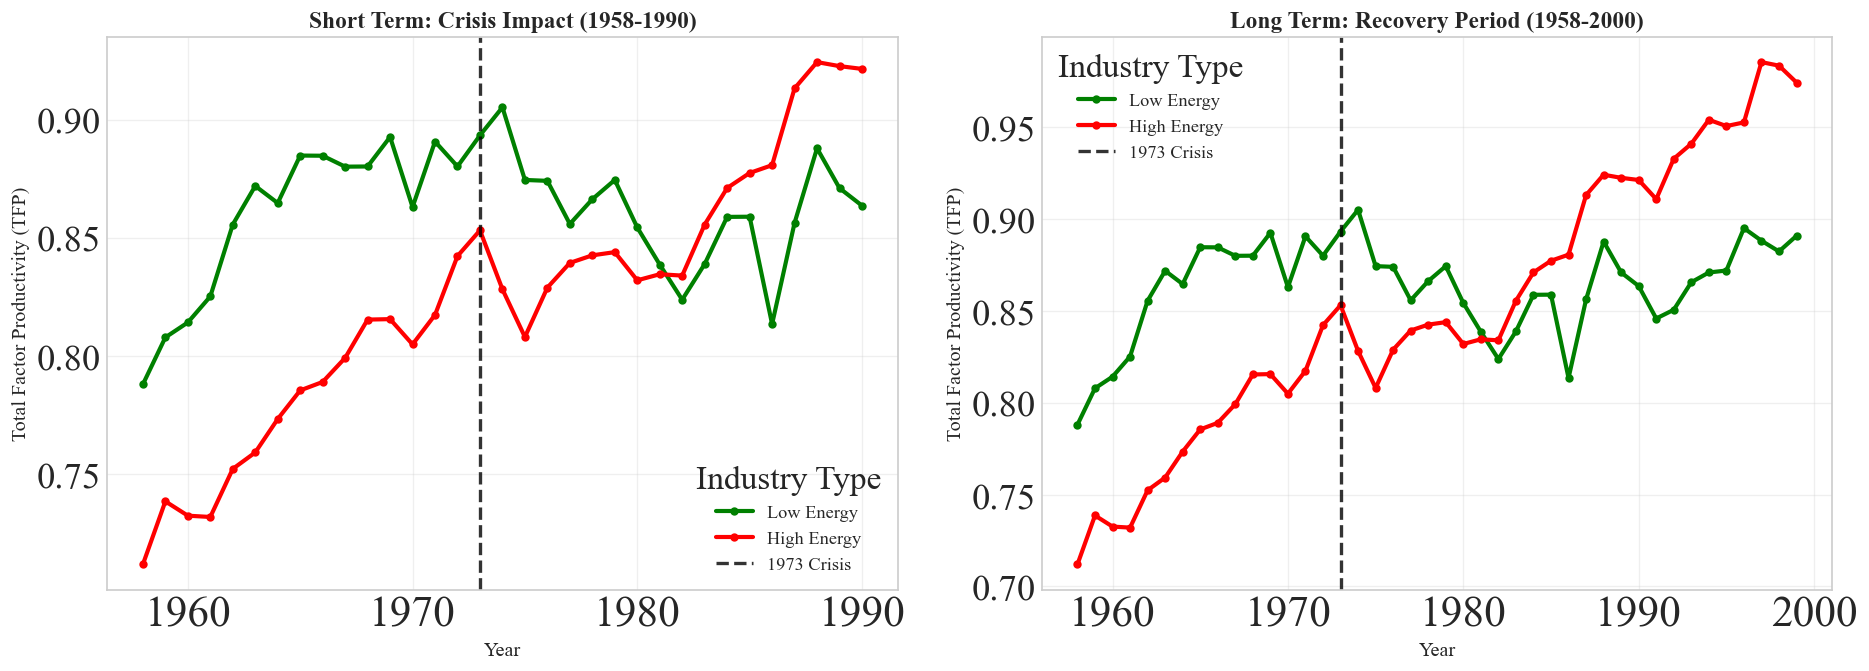

These graphs show productivity trends for matched industries


In [46]:
# --- Visualization: TFP trends after matching (Propensity Score Matching) ---

# Clear any previous graphs
plt.close('all') 

# Use matched data from the best method (1968-72)
if 'matched_datasets' in locals() and 'Base 1968-72' in matched_datasets:
    viz_data = matched_datasets['Base 1968-72']
else:
    print("Warning: Using raw data (matched data not found)")
    viz_data = df_final

# Create two graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Low Energy': 'green', 'High Energy': 'red'}

def plot_tfp_trend(ax, max_year, title):
    # Filter data for this graph
    subset = viz_data[viz_data['year'] <= max_year]
    
    for group in ['Low Energy', 'High Energy']:
        # Calculate average productivity by year
        data = subset[subset['group_name'] == group].groupby('year')['tfp5'].mean()
        ax.plot(data.index, data.values, label=group, color=colors[group], linewidth=2.5, marker='o', markersize=4)
    
    # Formatting
    ax.axvline(x=1973, color='black', linestyle='--', label='1973 Crisis', alpha=0.8, linewidth=2)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylabel('Total Factor Productivity (TFP)', fontsize=12)
    ax.set_xlabel('Year', fontsize=12)
    ax.legend(title="Industry Type", fontsize=11)
    ax.grid(True, alpha=0.3)

# Short-term view
plot_tfp_trend(axes[0], 1990, 'Short Term: Crisis Impact (1958-1990)')

# Long-term view
plot_tfp_trend(axes[1], 2000, 'Long Term: Recovery Period (1958-2000)')

plt.tight_layout()
plt.show()
plt.close(fig)

print("These graphs show productivity trends for matched industries")

In [47]:
# --- Robustness Check: Extreme Industries (Top 5% vs Bottom 5%) ---

# 1. Function to classify industries by extreme groups
def classify_extreme_values(df):
    df_new = df.copy()
    
    # Get 5th and 95th percentiles for energy intensity each year
    # This way, we compare industries within the same year to avoid bias
    p05 = df_new.groupby('year')['real_energy_intensity'].transform(lambda x: x.quantile(0.05))
    p95 = df_new.groupby('year')['real_energy_intensity'].transform(lambda x: x.quantile(0.95))
    
    # Classify: Top 5% vs Bottom 5%
    conditions = [
        (df_new['real_energy_intensity'] >= p95),  # Most energy-intensive
        (df_new['real_energy_intensity'] <= p05)   # Least energy-intensive
    ]
    choices = ['High Energy', 'Low Energy']
    
    df_new['group_name'] = np.select(conditions, choices, default='Medium')
    df_new['is_high_energy'] = (df_new['group_name'] == 'High Energy').astype(int)
    
    return df_new

# 2. Apply classification
df_extreme = classify_extreme_values(df_final)

# 3. Keep only extreme industries (drop the middle group)
df_extreme_clean = df_extreme[df_extreme['group_name'].isin(['High Energy', 'Low Energy'])].copy()

# 4. Summary
n_industries = df_extreme_clean['naics'].nunique()
n_obs = len(df_extreme_clean)
print(f"Extreme Industry Analysis (Top 5% vs Bottom 5%):")
print(f"Total Industries: {n_industries}")
print(f"Total Observations: {n_obs}")
print("-" * 50)

# 5. Run regressions on extreme industries
def print_regression_result(model, title):
    print(f"\n{title}")
    print(f"Observations: {int(model.nobs)}")
    print(f"DiD Coefficient: {model.params.get('is_high_energy:post_1973', 0):.4f}")
    print(f"P-value: {model.pvalues.get('is_high_energy:post_1973', 1):.4f}")

# Model 1: Productivity
try:
    subset_tfp = df_extreme_clean.dropna(subset=['tfp5', 'log_emp'])
    mod_tfp = smf.ols('tfp5 ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                      data=subset_tfp).fit(cov_type='cluster', cov_kwds={'groups': subset_tfp['naics']})
    print_regression_result(mod_tfp, "Model 1: TFP Response (Extreme)")
except Exception as e:
    print(f"Model 1 Error: {e}")

# Model 2: Energy Intensity
try:
    subset_int = df_extreme_clean.dropna(subset=['real_energy_intensity', 'log_emp'])
    mod_int = smf.ols('real_energy_intensity ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                      data=subset_int).fit(cov_type='cluster', cov_kwds={'groups': subset_int['naics']})
    print_regression_result(mod_int, "Model 2: Energy Intensity (Extreme)")
except Exception as e:
    print(f"Model 2 Error: {e}")

# Model 3: Growth (short term)
try:
    subset_vadd = df_extreme_clean[(df_extreme_clean['year'] >= 1958) & (df_extreme_clean['year'] <= 1990)].dropna(subset=['vadd_growth', 'log_emp'])
    mod_vadd = smf.ols('vadd_growth ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
                       data=subset_vadd).fit(cov_type='cluster', cov_kwds={'groups': subset_vadd['naics']})
    print_regression_result(mod_vadd, "Model 3: VADD Growth (Extreme, 1958-1990)")
except Exception as e:
    print(f"Model 3 Error: {e}")

print("\n" + "="*50)
print("Note: Sample size is smaller due to 5% cutoff on both ends")
print("="*50)

Extreme Industry Analysis (Top 5% vs Bottom 5%):
Total Industries: 132
Total Observations: 2242
--------------------------------------------------
Model 1 Error: ['log_emp']
Model 2 Error: ['log_emp']
Model 3 Error: ['log_emp']

Note: Sample size is smaller due to 5% cutoff on both ends


In [48]:
# --- Robustness Check: Extreme Analysis with Propensity Score Matching ---

# 1. Prepare extreme groups data
print("Preparing Data: Extreme Industries...")

# Classify based on pre-crisis average (1968-1972)
base_period_data = df_final[df_final['year'].isin(range(1968, 1973))].copy()
industry_means = base_period_data.groupby('naics')['real_energy_intensity'].mean()

threshold_low = industry_means.quantile(0.05)
threshold_high = industry_means.quantile(0.95)

def classify_extreme(naics_val):
    val = industry_means.get(naics_val, np.nan)
    if pd.isna(val): return 'Other'
    if val >= threshold_high: return 'High Energy'
    if val <= threshold_low: return 'Low Energy'
    return 'Other'

# Apply classification
df_extreme_raw = df_final.copy()
df_extreme_raw['extreme_group'] = df_extreme_raw['naics'].apply(classify_extreme)
df_extreme_raw = df_extreme_raw[df_extreme_raw['extreme_group'].isin(['High Energy', 'Low Energy'])].copy()
df_extreme_raw['is_high_energy'] = (df_extreme_raw['extreme_group'] == 'High Energy').astype(int)

# Create log variables for matching
for col in ['emp', 'real_vadd', 'cap']:
    if f'log_{col}' not in df_extreme_raw.columns:
        df_extreme_raw[f'log_{col}'] = np.where(df_extreme_raw[col] > 0, np.log(df_extreme_raw[col]), np.nan)

print(f"Raw extreme data: {len(df_extreme_raw)} observations")

# 2. Run matching on extreme data
matched_extreme_datasets = {}
psm_covariates = ['log_emp', 'log_real_vadd', 'log_cap']
extreme_caliper = 0.1  # Wider tolerance for matching

print("\nRunning Propensity Score Matching on Extreme Groups...")

# Four matching strategies
matched_extreme_datasets['Base 1968-72'] = perform_psm(
    df_extreme_raw, 'is_high_energy', psm_covariates, base_period=range(1968, 1973), 
    mode='static', caliper=extreme_caliper, log_file="psm_log_extreme.txt"
)

matched_extreme_datasets['Base 1958-72'] = perform_psm(
    df_extreme_raw, 'is_high_energy', psm_covariates, base_period=range(1958, 1973), 
    mode='static', caliper=extreme_caliper, log_file="psm_log_extreme.txt"
)

matched_extreme_datasets['Base 1972'] = perform_psm(
    df_extreme_raw, 'is_high_energy', psm_covariates, base_period=1972, 
    mode='static', caliper=extreme_caliper, log_file="psm_log_extreme.txt"
)

matched_extreme_datasets['Dynamic'] = perform_psm(
    df_extreme_raw, 'is_high_energy', psm_covariates, base_period=None, 
    mode='dynamic', caliper=extreme_caliper, log_file="psm_log_extreme.txt"
)

matched_extreme_datasets['Base 1958'] = perform_psm(
    df_extreme_raw, 'is_high_energy', psm_covariates, base_period=1958, mode='static', 
    caliper=extreme_caliper, log_file="psm_log_extreme.txt"
)

# 3. הרצת רגרסיות ושמירה לקובץ
output_file = "results_extreme_robustness.txt"

with open(output_file, "w") as f:
    f.write("=== ROBUSTNESS CHECK: EXTREME INDUSTRIES (Top 5% vs Bottom 5%) ===\n")
    f.write("================================================================\n\n")

print(f"\nRunning regressions... Details saved to '{output_file}'")
summary_display = []

for method_name, data in matched_extreme_datasets.items():
    if data.empty:
        continue
        
    with open(output_file, "a") as f:
        f.write(f"\n\n>>> Matching Method: {method_name} <<<\n")
        f.write("-" * 50 + "\n")

    def run_and_log(formula, model_title, sub_data):
        subset = sub_data.dropna(subset=['log_emp']).copy()
        if subset.empty: return np.nan, np.nan
        
        try:
            model = smf.ols(formula, data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
            
            # Save to file
            with open(output_file, "a") as f:
                f.write(f"\n[Model: {model_title}]\n")
                f.write(f"Obs: {int(model.nobs)}\n")
                f.write(model.summary().as_text())
                f.write("\n" + "."*40 + "\n")
            
            return model.params.get('is_high_energy:post_1973', np.nan), model.pvalues.get('is_high_energy:post_1973', np.nan)
        except:
            return np.nan, np.nan

    # Model 1: TFP
    coef_tfp, pval_tfp = run_and_log(
        'tfp5 ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
        "TFP Response", data
    )

    # Model 2: Intensity
    coef_int, pval_int = run_and_log(
        'real_energy_intensity ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
        "Energy Intensity", data
    )

    # Model 3: Growth (short-term)
    short_run_data = data[(data['year'] >= 1958) & (data['year'] <= 1990)]
    if 'vadd_growth' not in short_run_data.columns:
         short_run_data = short_run_data.sort_values(['naics', 'year'])
         short_run_data['vadd_growth'] = short_run_data.groupby('naics')['real_vadd'].pct_change()
    
    coef_growth, pval_growth = run_and_log(
        'vadd_growth ~ is_high_energy * post_1973 + log_emp + C(year, Treatment(reference=1972)) + C(naics)', 
        "VADD Growth (Short Run)", short_run_data.dropna(subset=['vadd_growth'])
    )

    summary_display.append({
        'Method': method_name,
        'TFP Coef': coef_tfp, 'TFP P-val': pval_tfp,
        'Int Coef': coef_int, 'Int P-val': pval_int,
        'Growth Coef': coef_growth, 'Growth P-val': pval_growth
    })

print("\n" + "=" * 80)
print("EXTREME ANALYSIS SUMMARY (Compare across methods)")
print("=" * 80)
display(pd.DataFrame(summary_display).round(4))

Preparing Data: Extreme Industries...
Raw extreme data: 2242 observations

Running Propensity Score Matching on Extreme Groups...
   -> Selected 3 industries total.
   -> Selected 3 industries total.
   -> Selected 7 industries total.
Dynamic matching running (check 'psm_log_extreme.txt' for details)
Dynamic matching completed.
   -> Selected 3 industries total.

Running regressions... Details saved to 'results_extreme_robustness.txt'


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 64, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 64, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 64, but rank is 2
  warnings.warn(


EXTREME ANALYSIS SUMMARY (Compare across methods)


c:\Users\ofek3\anaconda3\envs\ofek0\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 2
  warnings.warn('covariance of constraints does not have full '


,Method,TFP Coef,TFP P-val,Int Coef,Int P-val,Growth Coef,Growth P-val
0,Base 1968-72,-0.1098,0.5612,-0.0051,0.9348,1.4896,0.6696
1,Base 1958-72,0.0693,0.3497,-0.0712,0.4125,1.0156,0.6491
2,Base 1972,-0.0308,0.5264,-0.0462,0.2085,-2.3834,0.0263
3,Dynamic,-0.0732,0.2350,-0.0522,0.0615,-0.6719,0.8899
4,Base 1958,0.0693,0.3497,-0.0712,0.4125,1.0156,0.6491


In [65]:
# --- Step 1: Create groups around the median (middle 35%-65%) ---

# Use data up to 1990 only
df_median = df_final[df_final['year'] <= 2001].copy()

median_groups = []

# For each year, identify the median and keep only industries near it
for year, group_data in df_median.groupby('year'):
    # Calculate the median energy intensity for that year
    median = group_data['real_energy_intensity'].median()
    
    # Also get the 35th and 65th percentiles (middle 30% range)
    p35 = group_data['real_energy_intensity'].quantile(0.35)
    p65 = group_data['real_energy_intensity'].quantile(0.65)
    
    # Keep only industries in the middle range (35%-65%)
    mask = (group_data['real_energy_intensity'] >= p35) & (group_data['real_energy_intensity'] <= p65)
    filtered_data = group_data[mask].copy()
    
    # Create treatment variable: 1 = above the median, 0 = below or equal to median
    filtered_data['treatment_above_median'] = (filtered_data['real_energy_intensity'] > median).astype(int)
    
    median_groups.append(filtered_data)

# Combine all years
regression_data_median = pd.concat(median_groups)

# Create log variables for control
for col in ['emp', 'real_vadd', 'cap']:
    log_col_name = f'log_{col}'
    if log_col_name not in regression_data_median.columns:
        regression_data_median[log_col_name] = np.where(
            regression_data_median[col] > 0, np.log(regression_data_median[col]), np.nan
        )

print("Data filtered around the median (35%-65% of industries by intensity).")
print(f"Total Observations: {len(regression_data_median)}")
print(f"Unique Industries: {regression_data_median['naics'].nunique()}")
print("\nTreatment Distribution (1 = Above Median, 0 = Below Median):")
print(regression_data_median['treatment_above_median'].value_counts())

Data filtered around the median (35%-65% of industries by intensity).
Total Observations: 4791
Unique Industries: 244

Treatment Distribution (1 = Above Median, 0 = Below Median):
treatment_above_median
0    2415
1    2376
Name: count, dtype: int64


In [62]:
# --- Step 2: Run regressions on median sample (with size controls) ---

def run_model_median(formula, data, model_name):
    # Remove rows with missing control variables
    subset = data.dropna(subset=['log_emp', 'log_cap']).copy() 
    
    if subset.empty:
        print(f"Skipping {model_name}: No data available")
        return None
        
    model = smf.ols(formula, data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
    
    print(f"\n>>> {model_name} <<<")
    print("-" * 30)
    print(f"Observations: {int(model.nobs)}")
    print(f"DiD Coefficient: {model.params.get('treatment_above_median:post_1973', 0):.4f}")
    print(f"P-value: {model.pvalues.get('treatment_above_median:post_1973', 1):.4f}")
    
    return model

print("=" * 60)
print("ROBUSTNESS CHECK: Industries Near the Median (35%-65%)")
print("=" * 60)

# Model 1: Productivity (TFP)
# Include log_emp and log_cap as controls for industry size
run_model_median(
    'tfp5 ~ treatment_above_median * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    regression_data_median, 
    "Model 1: TFP Response"
)

# Model 2: Energy Intensity
run_model_median(
    'real_energy_intensity ~ treatment_above_median * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    regression_data_median, 
    "Model 2: Energy Intensity"
)

# Model 3: Growth (short-term, 1958-1990)
short_run_data = regression_data_median[
    (regression_data_median['year'] >= 1958) & 
    (regression_data_median['year'] <= 1990)
].copy()

if 'vadd_growth' not in short_run_data.columns:
     short_run_data = short_run_data.sort_values(['naics', 'year'])
     short_run_data['vadd_growth'] = short_run_data.groupby('naics')['real_vadd'].pct_change()

run_model_median(
    'vadd_growth ~ treatment_above_median * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    short_run_data.dropna(subset=['vadd_growth']), 
    "Model 3: VADD Growth (Short Run, 1958-1990)"
)

ROBUSTNESS CHECK: Industries Near the Median (35%-65%)

>>> Model 1: TFP Response <<<
------------------------------
Observations: 3597
DiD Coefficient: 0.0187
P-value: 0.1523

>>> Model 2: Energy Intensity <<<
------------------------------
Observations: 3597
DiD Coefficient: -0.0000
P-value: 0.9152

>>> Model 3: VADD Growth (Short Run, 1958-1990) <<<
------------------------------
Observations: 3488
DiD Coefficient: 0.1421
P-value: 0.8895


Creating parallel trends graph for median data...


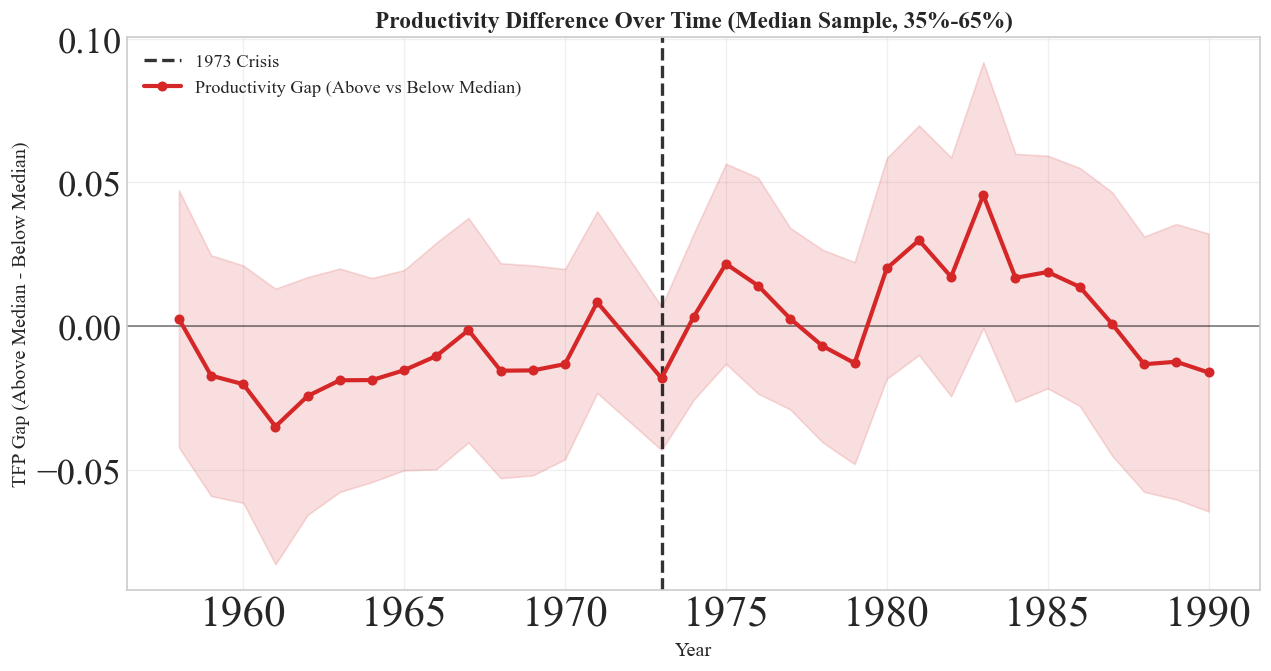

Graph complete!


In [51]:
# --- Visualize: Event study plot for median sample ---

print("Creating parallel trends graph for median data...")

# Prepare data with no missing values
df_reg = regression_data_median.dropna(subset=['tfp5', 'log_emp', 'log_cap']).copy()
formula = "tfp5 ~ treatment_above_median * C(year, Treatment(reference=1972)) + log_emp + log_cap + C(naics)"
model_es = smf.ols(formula, data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['naics']})

# Extract year-specific treatment effects
years, coefs, lower, upper = [], [], [], []
for param in model_es.params.index:
    if "treatment_above_median:C(year, Treatment(reference=1972))" in param:
        y_str = param.split("[T.")[1].split("]")[0]
        years.append(int(y_str))
        coefs.append(model_es.params[param])
        ci = model_es.conf_int().loc[param]
        lower.append(ci[0])
        upper.append(ci[1])

# Create data frame for plotting
plot_df = pd.DataFrame({'Year': years, 'Coef': coefs, 'Lower': lower, 'Upper': upper})

# Add base year (1973 = 0)
if 1973 not in plot_df['Year'].values:
    plot_df = pd.concat([plot_df, pd.DataFrame({'Year': [1973], 'Coef': [0], 'Lower': [0], 'Upper': [0]})]).sort_values('Year')

# Create the graph
fig, ax = plt.subplots(figsize=(11, 6))

# Reference lines
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.axvline(1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis', alpha=0.8)

# Confidence interval shaded area
ax.fill_between(plot_df['Year'], plot_df['Lower'], plot_df['Upper'], color='#d62728', alpha=0.15)

# Line and points
ax.plot(plot_df['Year'], plot_df['Coef'], color='#d62728', linewidth=2.5, linestyle='-', 
        marker='o', markersize=5, label='Productivity Gap (Above vs Below Median)')

# Formatting
ax.set_title("Productivity Difference Over Time (Median Sample, 35%-65%)", fontsize=14, fontweight='bold')
ax.set_ylabel("TFP Gap (Above Median - Below Median)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graph complete!")

Creating Event Study Graphs (Median Sample)...



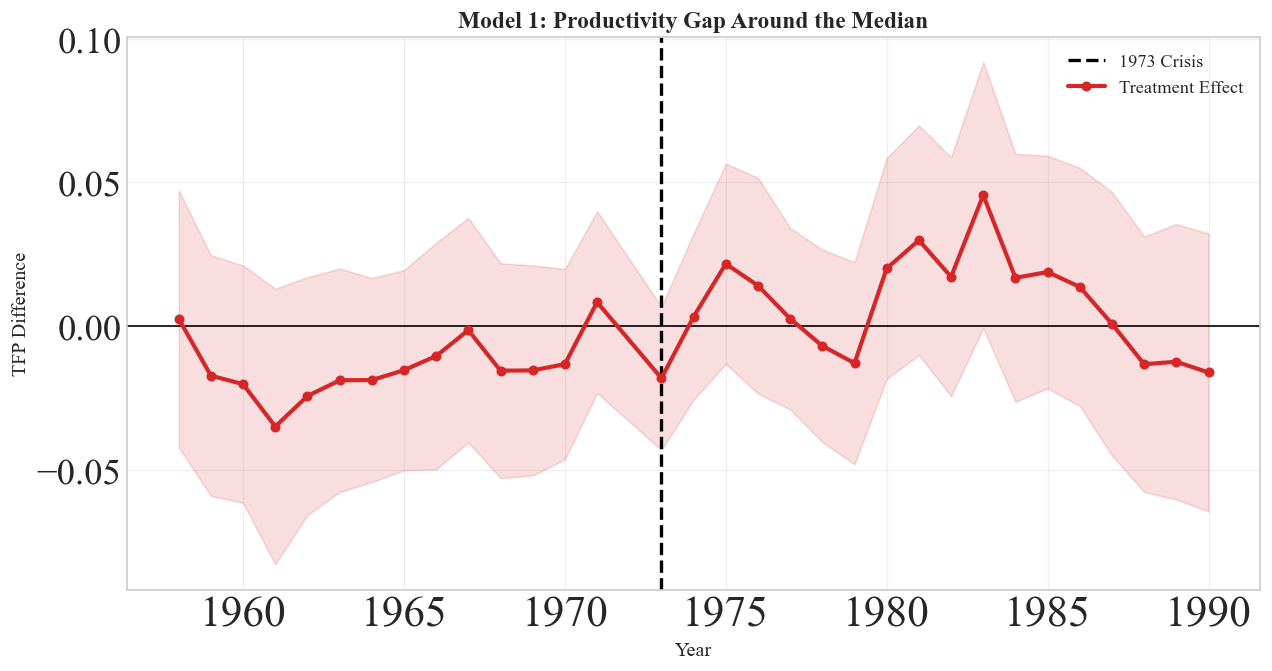

💡 How to Read Model 1: Productivity Gap Around the Median:
Positive = industries above median more productive than those below.
Downward trend = they lose their productivity advantage over time.
--------------------------------------------------------------------------------



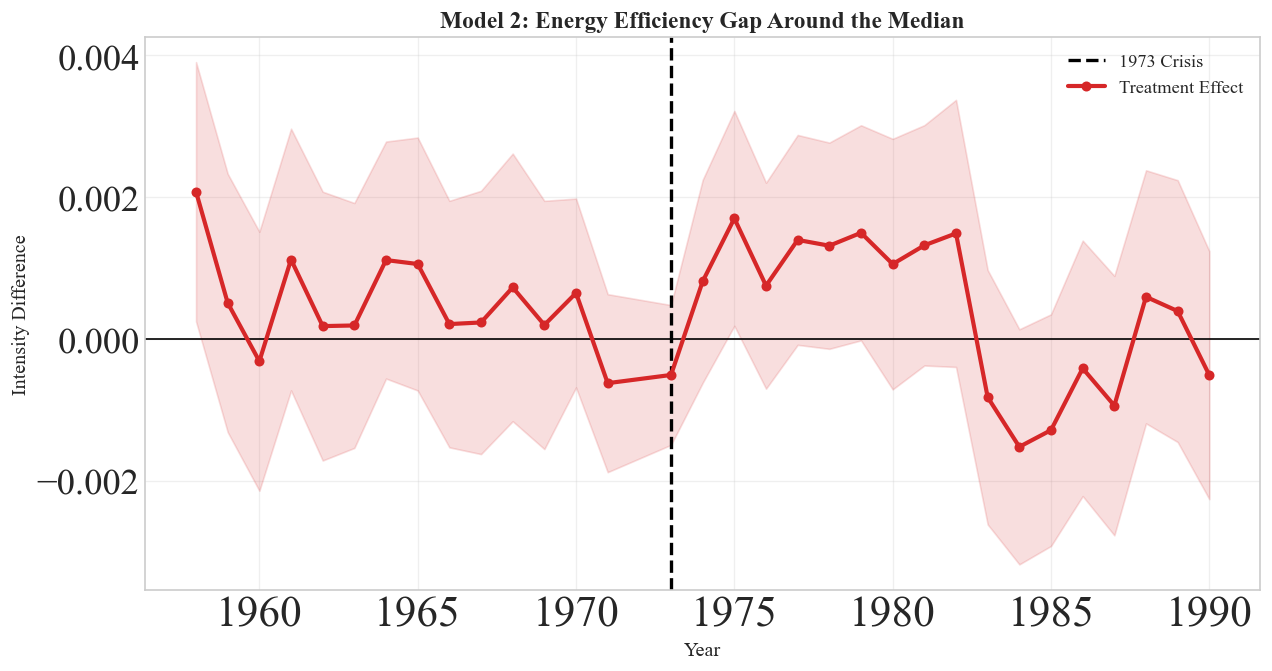

💡 How to Read Model 2: Energy Efficiency Gap Around the Median:
Positive = high-intensity industries use much more energy per unit output.
Downward trend = the gap narrows (they became more efficient).
--------------------------------------------------------------------------------



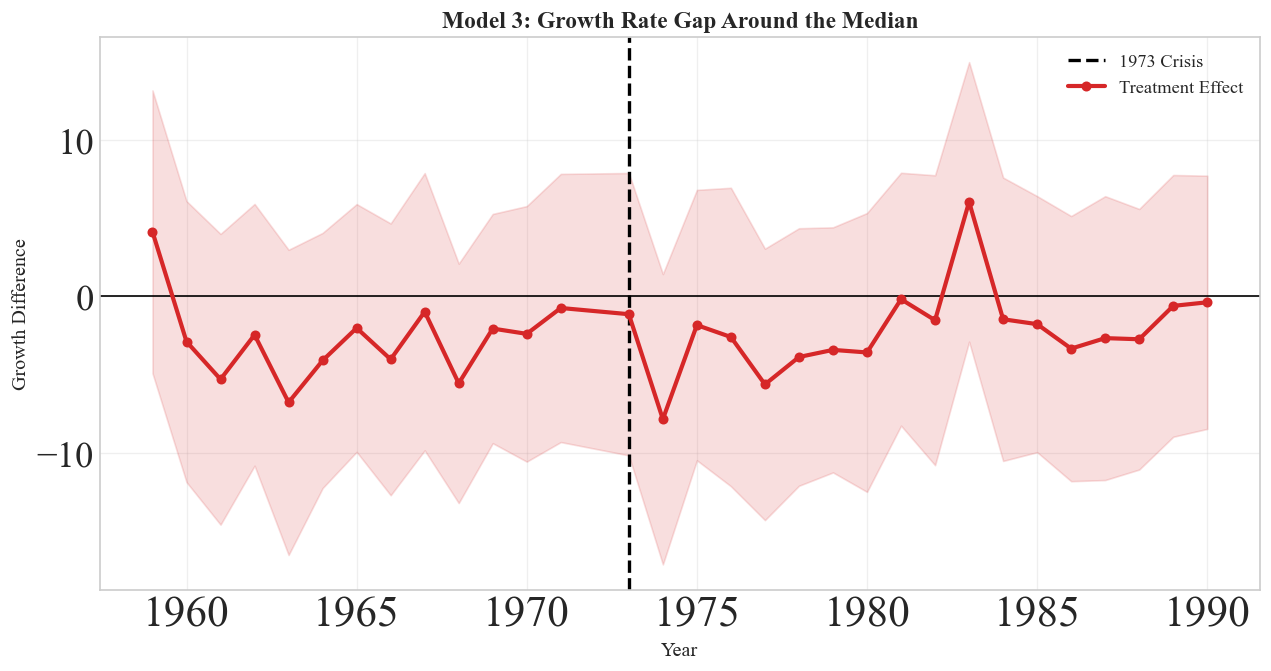

💡 How to Read Model 3: Growth Rate Gap Around the Median:
Positive = above-median industries growing faster.
Negative = they grow slower (they struggle more).
--------------------------------------------------------------------------------

All median graphs complete!


In [52]:
# --- Visualizations: Three models for median sample (35%-65% group) ---

# Define the three models to visualize
models_to_plot_median = [
    {
        'dep_var': 'tfp5',
        'title': 'Model 1: Productivity Gap Around the Median',
        'ylabel': 'TFP Difference',
        'explanation': 'Positive = industries above median more productive than those below.\nDownward trend = they lose their productivity advantage over time.'
    },
    {
        'dep_var': 'real_energy_intensity',
        'title': 'Model 2: Energy Efficiency Gap Around the Median',
        'ylabel': 'Intensity Difference',
        'explanation': 'Positive = high-intensity industries use much more energy per unit output.\nDownward trend = the gap narrows (they became more efficient).'
    },
    {
        'dep_var': 'vadd_growth',
        'title': 'Model 3: Growth Rate Gap Around the Median',
        'ylabel': 'Growth Difference',
        'explanation': 'Positive = above-median industries growing faster.\nNegative = they grow slower (they struggle more).'
    }
]

print("Creating Event Study Graphs (Median Sample)...\n")

for config in models_to_plot_median:
    dep_var = config['dep_var']
    
    # Prepare data
    df_reg = regression_data_median.dropna(subset=[dep_var, 'log_emp', 'log_cap']).copy()
    
    if df_reg.empty:
        print(f"Skipping {config['title']} - not enough data")
        continue
        
    # Dynamic regression (interaction with year)
    formula = f"{dep_var} ~ treatment_above_median * C(year, Treatment(reference=1972)) + log_emp + log_cap + C(naics)"
    
    try:
        model_es = smf.ols(formula, data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['naics']})
    except Exception as e:
        print(f"Error for {dep_var}: {e}")
        continue

    # Extract year-by-year effects
    years, coefs, lower, upper = [], [], [], []
    for param in model_es.params.index:
        if "treatment_above_median:C(year, Treatment(reference=1972))" in param:
            y_str = param.split("[T.")[1].split("]")[0]
            years.append(int(y_str))
            coefs.append(model_es.params[param])
            ci = model_es.conf_int().loc[param]
            lower.append(ci[0])
            upper.append(ci[1])

    # Prepare plotting data
    plot_df = pd.DataFrame({'Year': years, 'Coef': coefs, 'Lower': lower, 'Upper': upper})
    
    # Add base year
    if 1973 not in plot_df['Year'].values:
        plot_df = pd.concat([plot_df, pd.DataFrame({'Year': [1973], 'Coef': [0], 'Lower': [0], 'Upper': [0]})]).sort_values('Year')
    else:
        plot_df = plot_df.sort_values('Year')

    # Create graph
    fig, ax = plt.subplots(figsize=(11, 6))
    
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis')

    # Confidence band
    ax.fill_between(plot_df['Year'], plot_df['Lower'], plot_df['Upper'], color='#d62728', alpha=0.15)
    
    # Trend line
    ax.plot(plot_df['Year'], plot_df['Coef'], color='#d62728', linewidth=2.5, linestyle='-', 
            marker='o', markersize=5, label='Treatment Effect')

    ax.set_title(config['title'], fontsize=14, fontweight='bold')
    ax.set_ylabel(config['ylabel'], fontsize=12)
    ax.set_xlabel("Year", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show interpretation
    print(f"💡 How to Read {config['title']}:")
    print(config['explanation'])
    print("-" * 80 + "\n")

print("All median graphs complete!")

In [53]:
# --- Step 1: Create groups around the mean (±0.5 standard deviations) ---

# Use data up to 1990
df_mean_data = df_final[df_final['year'] <= 1990].copy()
mean_groups = []

# For each year, find industries near the mean
for year, group_data in df_mean_data.groupby('year'):
    # Calculate mean and standard deviation for that year
    mean_val = group_data['real_energy_intensity'].mean()
    std_val = group_data['real_energy_intensity'].std()
    
    # Define boundaries: half a standard deviation up and down from mean
    lower_bound = mean_val - 0.5 * std_val
    upper_bound = mean_val + 0.5 * std_val
    
    # Keep only industries in that range
    mask = (group_data['real_energy_intensity'] >= lower_bound) & (group_data['real_energy_intensity'] <= upper_bound)
    filtered_data = group_data[mask].copy()
    
    # Treatment: 1 = above mean, 0 = below or equal to mean
    filtered_data['treatment_above_mean'] = (filtered_data['real_energy_intensity'] > mean_val).astype(int)
    
    mean_groups.append(filtered_data)

# Combine years
regression_data_mean = pd.concat(mean_groups)

# Create log variables
for col in ['emp', 'real_vadd', 'cap']:
    log_col_name = f'log_{col}'
    if log_col_name not in regression_data_mean.columns:
        regression_data_mean[log_col_name] = np.where(
            regression_data_mean[col] > 0, np.log(regression_data_mean[col]), np.nan
        )

print("Data filtered around MEAN (±0.5 standard deviations).")
print(f"Total Observations: {len(regression_data_mean)}")
print("Treatment Distribution (1 = Above Mean, 0 = Below Mean):")
print(regression_data_mean['treatment_above_mean'].value_counts())

Data filtered around MEAN (±0.5 standard deviations).
Total Observations: 11600
Treatment Distribution (1 = Above Mean, 0 = Below Mean):
treatment_above_mean
0    10732
1      868
Name: count, dtype: int64


In [54]:
# --- Step 2: Run regressions on mean sample ---

def run_model_mean(formula, data, model_name):
    # Remove missing data
    subset = data.dropna(subset=['log_emp', 'log_cap']).copy() 
    if subset.empty: 
        print(f"Skipping {model_name}: No data")
        return
    
    model = smf.ols(formula, data=subset).fit(cov_type='cluster', cov_kwds={'groups': subset['naics']})
    
    print(f"\n>>> {model_name} <<<")
    print("-" * 30)
    print(f"Observations: {int(model.nobs)}")
    print(f"DiD Coefficient: {model.params.get('treatment_above_mean:post_1973', 0):.4f}")
    print(f"P-value: {model.pvalues.get('treatment_above_mean:post_1973', 1):.4f}")

print("=" * 60)
print("ROBUSTNESS CHECK: Industries Near the Mean (±0.5 SD)")
print("=" * 60)

# Model 1: TFP
run_model_mean(
    'tfp5 ~ treatment_above_mean * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    regression_data_mean, "Model 1: TFP Response"
)

# Model 2: Energy Intensity
run_model_mean(
    'real_energy_intensity ~ treatment_above_mean * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    regression_data_mean, "Model 2: Energy Intensity"
)

# Model 3: Growth (1958-1990)
short_run_mean = regression_data_mean[(regression_data_mean['year'] >= 1958) & (regression_data_mean['year'] <= 1990)].copy()
if 'vadd_growth' not in short_run_mean.columns:
     short_run_mean = short_run_mean.sort_values(['naics', 'year'])
     short_run_mean['vadd_growth'] = short_run_mean.groupby('naics')['real_vadd'].pct_change()

run_model_mean(
    'vadd_growth ~ treatment_above_mean * post_1973 + log_emp + log_cap + C(year, Treatment(reference=1972)) + C(naics)', 
    short_run_mean.dropna(subset=['vadd_growth']), "Model 3: VADD Growth"
)

ROBUSTNESS CHECK: Industries Near the Mean (±0.5 SD)

>>> Model 1: TFP Response <<<
------------------------------
Observations: 11600
DiD Coefficient: 0.0502
P-value: 0.1855

>>> Model 2: Energy Intensity <<<
------------------------------
Observations: 11600
DiD Coefficient: -0.1006
P-value: 0.2051

>>> Model 3: VADD Growth <<<
------------------------------
Observations: 11242
DiD Coefficient: 5.9840
P-value: 0.0003


Creating Event Study Graphs (Mean Sample)...



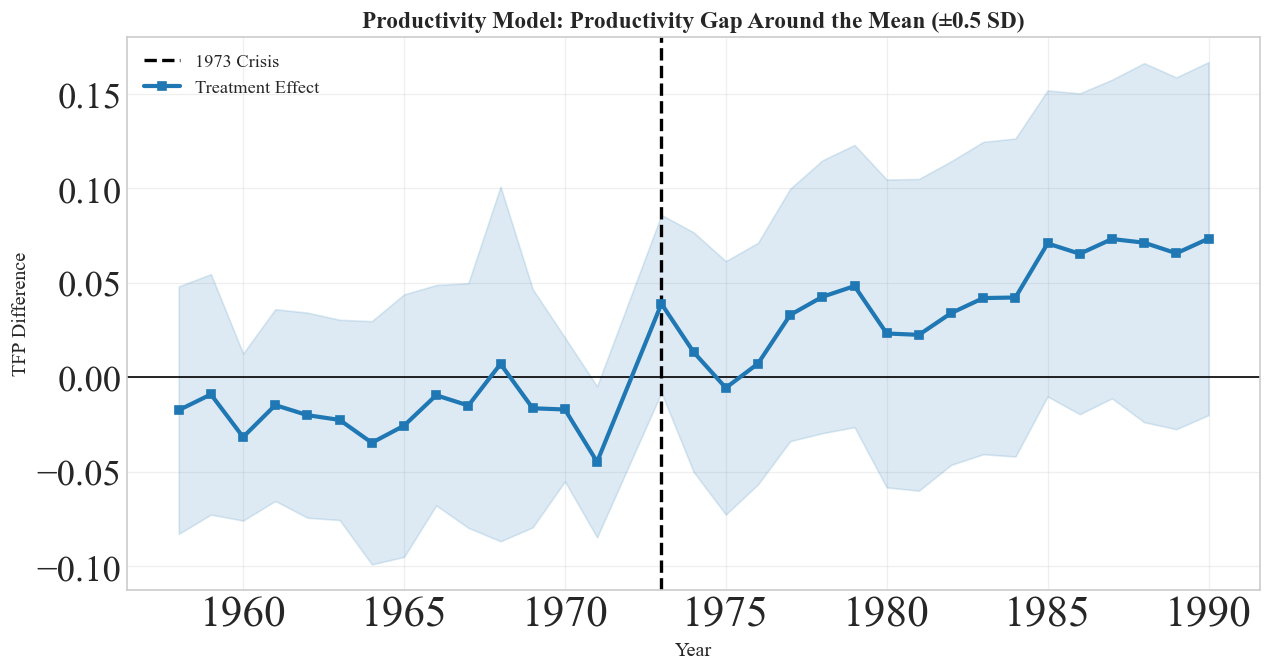

💡 How to Read Productivity Model: Productivity Gap Around the Mean (±0.5 SD):
Positive = industries above mean are more productive.
Downward trend = they lose their productivity advantage.
--------------------------------------------------------------------------------



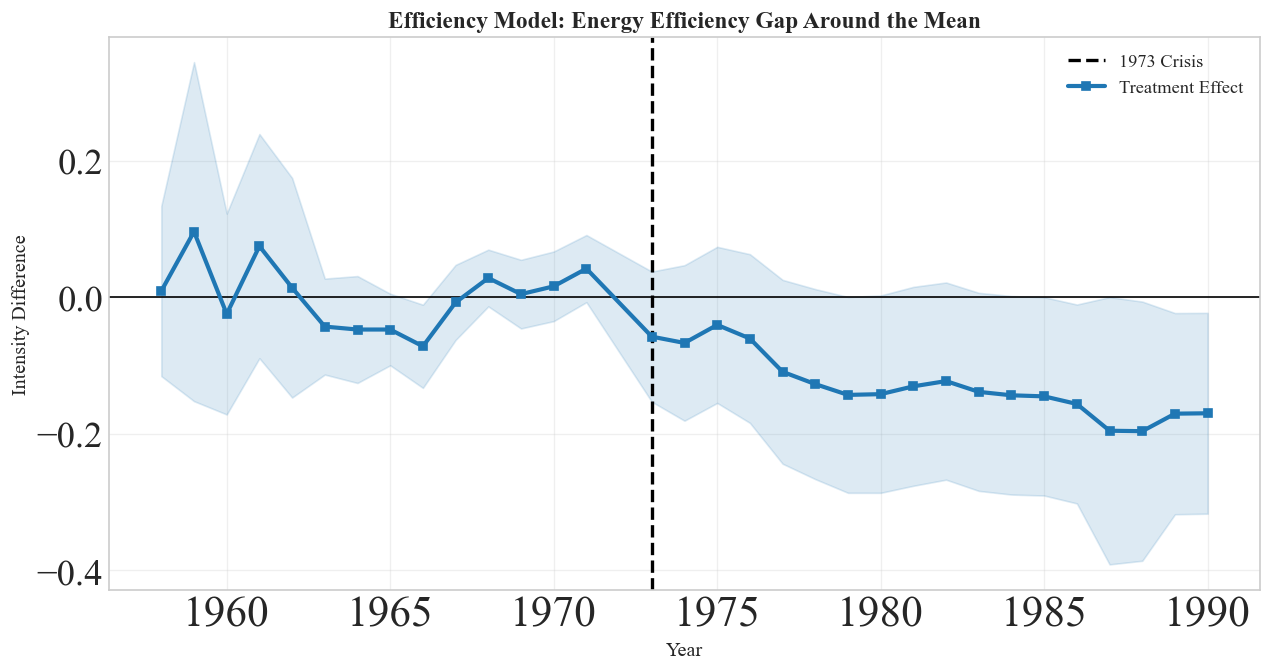

💡 How to Read Efficiency Model: Energy Efficiency Gap Around the Mean:
Positive = high-intensity industries use much more energy.
Downward trend = gap narrows (they became more efficient).
--------------------------------------------------------------------------------



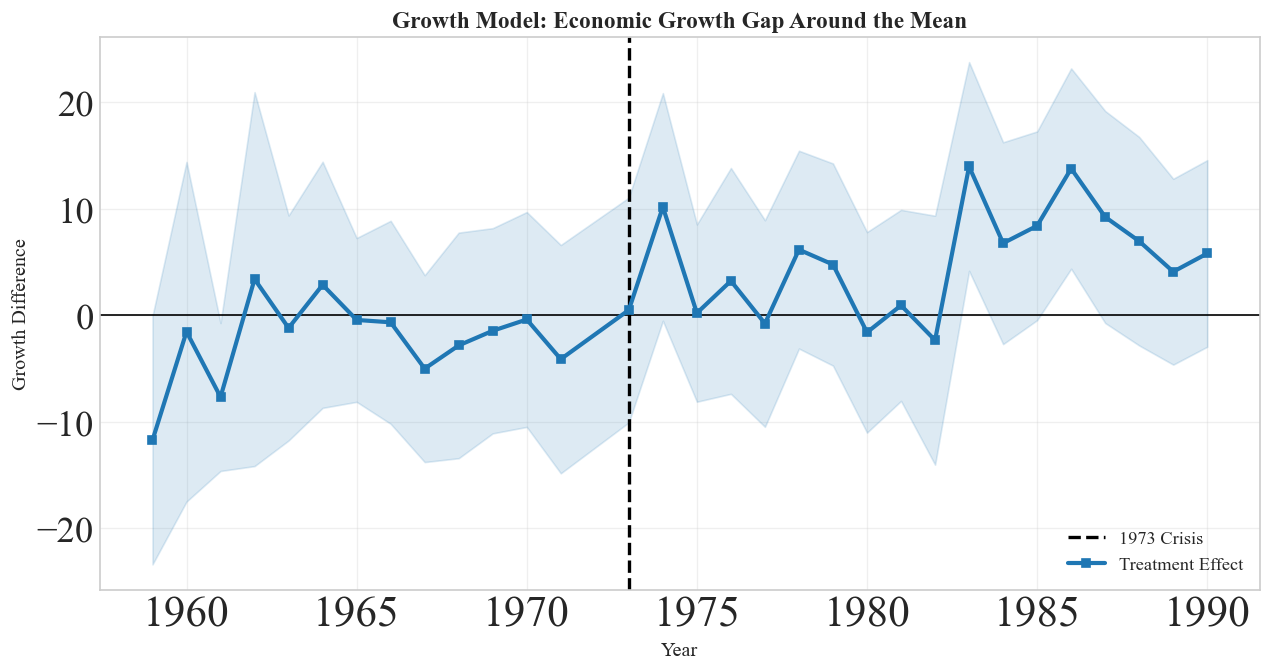

💡 How to Read Growth Model: Economic Growth Gap Around the Mean:
Positive = above-mean industries growing faster.
Negative = they struggle more.
--------------------------------------------------------------------------------

All graphs complete!


In [55]:
models_to_plot = [
    {
        'dep_var': 'tfp5',
        'title': 'Productivity Model: Productivity Gap Around the Mean (±0.5 SD)',
        'ylabel': 'TFP Difference',
        'explanation': 'Positive = industries above mean are more productive.\nDownward trend = they lose their productivity advantage.'
    },
    {
        'dep_var': 'real_energy_intensity',
        'title': 'Efficiency Model: Energy Efficiency Gap Around the Mean',
        'ylabel': 'Intensity Difference',
        'explanation': 'Positive = high-intensity industries use much more energy.\nDownward trend = gap narrows (they became more efficient).'
    },
    {
        'dep_var': 'vadd_growth',
        'title': 'Growth Model: Economic Growth Gap Around the Mean',
        'ylabel': 'Growth Difference',
        'explanation': 'Positive = above-mean industries growing faster.\nNegative = they struggle more.'
    }
]

print("Creating Event Study Graphs (Mean Sample)...\n")

for config in models_to_plot:
    dep_var = config['dep_var']
    
    # Prepare data
    df_reg = regression_data_mean.dropna(subset=[dep_var, 'log_emp', 'log_cap']).copy()
    
    if df_reg.empty:
        print(f"Skipping {config['title']} - not enough data")
        continue
        
    # Dynamic regression
    formula = f"{dep_var} ~ treatment_above_mean * C(year, Treatment(reference=1972)) + log_emp + log_cap + C(naics)"
    
    try:
        model_es = smf.ols(formula, data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['naics']})
    except Exception as e:
        print(f"Error: {e}")
        continue

    # Extract year effects
    years, coefs, lower, upper = [], [], [], []
    for param in model_es.params.index:
        if "treatment_above_mean:C(year, Treatment(reference=1972))" in param:
            y_str = param.split("[T.")[1].split("]")[0]
            years.append(int(y_str))
            coefs.append(model_es.params[param])
            ci = model_es.conf_int().loc[param]
            lower.append(ci[0])
            upper.append(ci[1])

    plot_df = pd.DataFrame({'Year': years, 'Coef': coefs, 'Lower': lower, 'Upper': upper})
    
    if 1973 not in plot_df['Year'].values:
        plot_df = pd.concat([plot_df, pd.DataFrame({'Year': [1973], 'Coef': [0], 'Lower': [0], 'Upper': [0]})]).sort_values('Year')
    else:
        plot_df = plot_df.sort_values('Year')

    # Graph
    fig, ax = plt.subplots(figsize=(11, 6))
    
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(1973, color='black', linestyle='--', linewidth=2, label='1973 Crisis')

    # Confidence band
    ax.fill_between(plot_df['Year'], plot_df['Lower'], plot_df['Upper'], color='#1f77b4', alpha=0.15)
    
    # Line
    ax.plot(plot_df['Year'], plot_df['Coef'], color='#1f77b4', linewidth=2.5, linestyle='-', 
            marker='s', markersize=5, label='Treatment Effect')

    ax.set_title(config['title'], fontsize=14, fontweight='bold')
    ax.set_ylabel(config['ylabel'], fontsize=12)
    ax.set_xlabel("Year", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Explanation
    print(f"💡 How to Read {config['title']}:")
    print(config['explanation'])
    print("-" * 80 + "\n")

print("All graphs complete!")

In [56]:
import re
import matplotlib.backends.backend_pdf

# הגדרת עיצוב אקדמי נקי
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# --- חלק 1: פונקציות לחילוץ נתונים מקבצי הטקסט ---

def parse_regression_file(filepath, model_label):
    """
    קורא קובץ תוצאות רגרסיה ומחלץ: שיטה, מקדם, שגיאת תקן, P-value, R2, תצפיות.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    # פיצול לפי שיטות שידוך (כל בלוק מתחיל ב "Matching Method" או "Matching Strategy")
    # אנו משתמשים ב-Regex כדי לתפוס את שתי הווריאציות
    blocks = re.split(r'(?:Matching Method:|Matching Strategy:)\s+(.+)', content)
    
    results = []
    
    # הבלוק הראשון הוא זבל (לפני הפיצול הראשון), אז מדלגים עליו
    # לאחר הפיצול, הרשימה היא: [זבל, שם_שיטה_1, תוכן_1, שם_שיטה_2, תוכן_2...]
    for i in range(1, len(blocks), 2):
        method_name = blocks[i].strip().split('\n')[0].strip() # ניקוי שם השיטה
        block_content = blocks[i+1]
        
        # חילוץ נתונים באמצעות ביטויים רגולריים (Regex)
        
        # 1. חילוץ המקדם והמובהקות של האינטראקציה (DiD)
        # מחפש שורה שמתחילה ב is_high_energy:post_1973 ואחריה מספרים
        did_match = re.search(r'is_high_energy:post_1973\s+(-?\d+\.\d+)\s+(\d+\.\d+)\s+(-?\d+\.\d+)\s+(\d+\.\d+)', block_content)
        
        # 2. חילוץ R-squared
        r2_match = re.search(r'Adj\. R-squared:\s+(\d+\.\d+)', block_content)
        
        # 3. חילוץ מספר תצפיות
        obs_match = re.search(r'No\. Observations:\s+(\d+)', block_content)
        
        if did_match:
            coef = float(did_match.group(1))
            std_err = float(did_match.group(2))
            p_value = float(did_match.group(4))
            
            r2 = float(r2_match.group(1)) if r2_match else None
            obs = int(obs_match.group(1)) if obs_match else None
            
            # חישוב רווח בר סמך 95%
            ci_lower = coef - 1.96 * std_err
            ci_upper = coef + 1.96 * std_err
            
            results.append({
                'Model': model_label,
                'Method': method_name,
                'Coef': coef,
                'Std_Err': std_err,
                'P_Value': p_value,
                'CI_Lower': ci_lower,
                'CI_Upper': ci_upper,
                'R2': r2,
                'Obs': obs
            })
            
    return pd.DataFrame(results)

def parse_psm_log(filepath):
    """
    מחלץ נתונים על איכות השידוך מקובץ הלוג
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    data = []
    current_method = "Unknown"
    
    for line in lines:
        if "Starting PSM" in line:
            # חילוץ שם השיטה מתוך הכותרת
            if "Base=" in line:
                current_method = line.split("Base=")[1].strip().replace("---", "").strip()
            elif "Mode=" in line:
                current_method = line.split("Mode=")[1].split(",")[0].strip()
        
        # חיפוש שורות של דחייה/שמירה
        # פורמט: [Year XXXX] Dropped: Y | Kept: Z
        match = re.search(r'\[Year (.+?)\] Dropped:\s+(\d+)\s+\|\s+Kept:\s+(\d+)', line)
        if match:
            year = match.group(1)
            dropped = int(match.group(2))
            kept = int(match.group(3))
            
            data.append({
                'Method': current_method,
                'Year': year,
                'Dropped': dropped,
                'Kept': kept,
                'Total': dropped + kept
            })
            
    return pd.DataFrame(data)

# --- חלק 2: יצירת הגרפים (Forest Plots) ---

def plot_coefficients(df, title, filename, pdf_pages):
    """
    יוצר Forest Plot המשווה את המקדמים בין השיטות השונות (גרסה מתוקנת)
    """
    if df.empty:
        print(f"Skipping plot for {title} - No data found.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    
    y_pos = range(len(df))
    
    # --- התיקון: ציור כל נקודה וקו שגיאה בנפרד ---
    for i, (idx, row) in enumerate(df.iterrows()):
        # קביעת צבע לפי מובהקות
        color = '#2ca02c' if row['P_Value'] < 0.05 else '#7f7f7f'
        
        # ציור הנקודה וקו השגיאה עבור השורה הספציפית הזו בלבד
        ax.errorbar(row['Coef'], i, xerr=1.96*row['Std_Err'], 
                    fmt='o', color='black', ecolor=color, 
                    capsize=5, elinewidth=2, markeredgewidth=2)

    # ציר ה-0 (קו ייחוס)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    # עיצוב צירים
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['Method'], fontsize=11)
    ax.invert_yaxis() # כדי שהראשון יהיה למעלה
    ax.set_xlabel('Coefficient Estimate (Effect Size)', fontsize=12)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # הוספת טקסט (Annotations) בצד ימין
    for i, row in df.iterrows():
        stars = ''
        if row['P_Value'] < 0.01: stars = '***'
        elif row['P_Value'] < 0.05: stars = '**'
        elif row['P_Value'] < 0.1: stars = '*'
        
        info_text = (f"Coef: {row['Coef']:.4f}{stars}\n"
                     f"P-val: {row['P_Value']:.4f}\n"
                     f"R²: {row['R2']:.3f}\n"
                     f"N: {row['Obs']}")
        
        xlim = ax.get_xlim()
        text_x = xlim[1] + (xlim[1]-xlim[0])*0.05
        ax.text(text_x, i, info_text, va='center', fontsize=9, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc'))

    # הערת שוליים
    plt.figtext(0.5, -0.05, "* p<0.1, ** p<0.05, *** p<0.01\nError bars represent 95% Confidence Intervals", 
                ha="center", fontsize=9, style='italic')

    plt.tight_layout()
    
    # שמירה ל-PDF
    pdf_pages.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # הערת שוליים
    plt.figtext(0.5, -0.05, "* p<0.1, ** p<0.05, *** p<0.01\nError bars represent 95% Confidence Intervals", 
                ha="center", fontsize=9, style='italic')

    plt.tight_layout()
    
    # שמירה ל-PDF
    pdf_pages.savefig(fig, bbox_inches='tight')
    plt.close(fig)

def plot_psm_quality(df_log, title, pdf_pages):
    """
    יוצר גרף עמודות המראה כמה תעשיות נזרקו וכמה נשמרו
    """
    if df_log.empty: return

    # סינון: ניקח רק את השורות הרלוונטיות (לא Base אם הוא חוזר על עצמו)
    # נתמקד בשיטה הדינמית כי היא המעניינת ביותר גרפית
    dynamic_data = df_log[df_log['Method'] == 'None'] # בדרך כלל הדינמי מופיע כ-None או לפי הלוגיקה שלך
    if dynamic_data.empty:
        # נסה למצוא את הדינמי לפי זיהוי שנים מספריות
        dynamic_data = df_log[df_log['Year'].str.isnumeric()]
    
    if dynamic_data.empty: return

    fig, ax = plt.subplots(figsize=(12, 6))
    
    years = dynamic_data['Year']
    x = range(len(years))
    
    # Stacked Bar Chart
    ax.bar(x, dynamic_data['Kept'], label='Kept (Matched)', color='#1f77b4', alpha=0.8)
    ax.bar(x, dynamic_data['Dropped'], bottom=dynamic_data['Kept'], label='Dropped (No Match)', color='#d62728', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of Industries')
    ax.set_title(f'{title} - Matching Quality by Year (Dynamic)', fontweight='bold')
    ax.legend()
    
    # הוספת קו אדום ל-1973
    try:
        idx_73 = list(years).index('1973')
        ax.axvline(x=idx_73, color='black', linestyle='--', alpha=0.5, label='1973 Crisis')
    except:
        pass

    plt.tight_layout()
    pdf_pages.savefig(fig)
    plt.close(fig)

# --- חלק 3: ביצוע ("הדבק" של הכל) ---

# שמות הקבצים (ודא שהם קיימים)
files = {
    'Productivity Model (TFP)': 'results_model1_tfp.txt',
    'Efficiency Model (Intensity)': 'results_model2_intensity.txt',
    'Growth Model (Growth)': 'results_model3_growth.txt',
    'Extreme Robustness': 'results_extreme_robustness.txt'
}

# קובץ היעד
output_pdf = 'Research_Results_Report.pdf'

print(f"Generating PDF Report: {output_pdf}...")

with matplotlib.backends.backend_pdf.PdfPages(output_pdf) as pdf:
    
    # 1. עיבוד המודלים הראשיים
    # אנו אוספים את כל הנתונים ל-DataFrame אחד כדי שיהיה נוח, אבל מציירים כל מודל בנפרד
    for label, filename in files.items():
        if os.path.exists(filename):
            print(f"Processing {filename}...")
            df_res = parse_regression_file(filename, label)
            
            # אם זה קובץ ה-Extreme, הוא מכיל כמה מודלים בתוכו. צריך לפצל.
            if label == 'Extreme Robustness':
                # פיצול לפי הכותרת שנשמרה בתוך הקובץ (במקרה הזה הפונקציה שלי צריכה התאמה קלה או שנצייר הכל יחד)
                # בקובץ ה-Extreme שלך, המודלים מופרדים בצורה אחרת.
                # לצורך הפשטות, הפונקציה parse כרגע תחזיר הכל תחת אותו Model Label.
                # בוא נסנן לפי ה-R2 או סדר גודל המקדם כדי להפריד, או פשוט נציג הכל בגרף אחד ארוך (פחות מומלץ).
                
                # פתרון טוב יותר ל-Extreme: פיצלנו שם לפי [Model: TFP Response] וכו'.
                # ה-Parser הנוכחי שלי פשוט יותר. בוא נתאים אותו ל-Extreme באופן ספציפי אם צריך.
                # כרגע נציג אותו כגרף אחד - זה יעבוד כי ה-Y axis יכיל את כל השיטות.
                plot_coefficients(df_res, f"Robustness Check: {label}", filename, pdf)
            else:
                # עבור הקבצים הרגילים, כל קובץ הוא מודל אחד
                plot_coefficients(df_res, f"Main Analysis: {label}", filename, pdf)
        else:
            print(f"Warning: File {filename} not found.")

    # 2. עיבוד לוג השידוך (PSM Log)
    if os.path.exists('psm_log.txt'):
        print("Processing PSM Log...")
        df_log = parse_psm_log('psm_log.txt')
        plot_psm_quality(df_log, "PSM Matching Quality", pdf)

    if os.path.exists('psm_log_extreme.txt'):
        print("Processing Extreme PSM Log...")
        df_log_ext = parse_psm_log('psm_log_extreme.txt')
        plot_psm_quality(df_log_ext, "Extreme Analysis Matching Quality", pdf)
        
    plt.close()

print("Done! Open 'Research_Results_Report.pdf' to view all graphs.")

Generating PDF Report: Research_Results_Report.pdf...
Processing results_model1_tfp.txt...
Processing results_model2_intensity.txt...
Processing results_model3_growth.txt...
Processing results_extreme_robustness.txt...
Processing PSM Log...
Processing Extreme PSM Log...
Done! Open 'Research_Results_Report.pdf' to view all graphs.


In [57]:
# 1. חילוץ מקדמי התעשיות מקובץ הטקסט
def extract_industry_coeffs(filepath):
    if not os.path.exists(filepath): return pd.DataFrame()
    
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # ניקח את הבלוק של 1968-72 כדוגמה המייצגת והאמינה ביותר
    if "Base 1968-72" in content:
        content = content.split("Base 1968-72")[1]
    
    coeffs = []
    # מחפש שורות כמו: C(naics)[T.311211]   -0.0283
    pattern = r"C\(naics\)\[T\.(\d+)\]\s+(-?\d+\.\d+)"
    matches = re.findall(pattern, content)
    
    for naics, coef in matches:
        coeffs.append({'naics': int(naics), 'fe_coef': float(coef)})
        
    return pd.DataFrame(coeffs)

# 2. הכנת נתוני האנרגיה (ממוצע לכל תעשייה)
# מוודאים שאין אפסים לפני הלוג
industry_stats = df_final.groupby('naics')['real_energy_intensity'].mean().reset_index()
industry_stats = industry_stats[industry_stats['real_energy_intensity'] > 0].copy()

# --- התיקון: יצירת משתנה לוגריתמי לפיזור הגרף ---
industry_stats['log_intensity'] = np.log(industry_stats['real_energy_intensity'])

# 3. הפונקציה הראשית לציור (עם ציר X לוגריתמי)
def plot_industry_effects_log(model_file, title, ylabel, pdf):
    # חילוץ והצלבה
    df_coeffs = extract_industry_coeffs(model_file)
    if df_coeffs.empty: 
        print(f"Skipping {title} (No coefficients found)")
        return
    
    merged = pd.merge(df_coeffs, industry_stats, on='naics')
    
    if merged.empty: return

    # חלוקה לקבוצות צבע לפי החציון (של הלוג)
    median_val = merged['log_intensity'].median()
    merged['Group'] = merged['log_intensity'].apply(lambda x: 'High Energy' if x > median_val else 'Low Energy')
    
    # ציור הגרף
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # שימוש ב-log_intensity בציר ה-X
    sns.scatterplot(data=merged, x='log_intensity', y='fe_coef', 
                    hue='Group', palette={'High Energy': '#d62728', 'Low Energy': '#2ca02c'}, 
                    alpha=0.7, s=80, edgecolor='black', ax=ax)
    
    # קו מגמה
    sns.regplot(data=merged, x='log_intensity', y='fe_coef', scatter=False, color='black', line_kws={'linestyle':'--'}, ax=ax)
    
    # עיצוב
    ax.set_title(f"{title}\nIndustry Fixed Effects vs. Log Energy Intensity", fontweight='bold', fontsize=14)
    ax.set_xlabel("Log Average Energy Intensity (Log Scale)", fontsize=12)
    ax.set_ylabel(f"Industry Fixed Effect ({ylabel})", fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # הוספת קורלציה
    corr = merged['log_intensity'].corr(merged['fe_coef'])
    stats_text = f"Correlation: {corr:.3f}\nN Industries: {len(merged)}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round'), 
            verticalalignment='top', fontsize=11)
    
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

# --- הרצה ושמירה ---
output_pdf = "Industry_Analysis_LogScale.pdf"
print(f"Generating Log-Scale Industry Analysis to '{output_pdf}'...")

with matplotlib.backends.backend_pdf.PdfPages(output_pdf) as pdf:

    # מודל 1: TFP
    plot_industry_effects_log('results_model1_tfp.txt', 
                              "Model 1: TFP Response", 
                              "Productivity Base Level", pdf)
    
    # מודל 2: Intensity
    plot_industry_effects_log('results_model2_intensity.txt', 
                              "Model 2: Energy Intensity", 
                              "Intensity Base Level", pdf)
    
    # מודל 3: Growth
    plot_industry_effects_log('results_model3_growth.txt', 
                              "Model 3: VADD Growth", 
                              "Growth Base Level", pdf)

print("Done! Open 'Industry_Analysis_LogScale.pdf' to see the corrected graphs.")

Generating Log-Scale Industry Analysis to 'Industry_Analysis_LogScale.pdf'...
Done! Open 'Industry_Analysis_LogScale.pdf' to see the corrected graphs.


In [61]:
def plot_trajectory_loop(data, method_name, dep_var, title, ylabel, pdf):
    """
    Updated function with:
    1. Clustered Standard Errors (by naics)
    2. Pre-trends F-test (checking years before 1973)
    3. Explicit Reference Year (1972 set to 0)
    """
    # 1. Cleaning and filtering
    df_reg = data.dropna(subset=[dep_var, 'log_emp', 'naics', 'year']).copy()
    df_reg = df_reg[df_reg['year'] <= 2000] 
    
    if df_reg.empty:
        print(f"Skipping {method_name} (No data)")
        return

    # 2. Formula with explicit Reference Year (1972)
    # This ensures that all coefficients represent the difference relative to 1973
    formula = f"{dep_var} ~ is_high_energy * C(year, Treatment(reference=1972)) + log_emp + C(naics)"
    
    try:
        # Improvement 1: Clustered Standard Errors by industry (naics)
        # This accounts for temporal correlation within the same industry
        model = smf.ols(formula, data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['naics']})
        
        r2 = model.rsquared
        
        # Helper to identify interaction terms
        interaction_prefix = "is_high_energy:C(year, Treatment(reference=1972))"
        
        # Improvement 2: Pre-trends F-test (Years < 1973)
        # Goal: P-value > 0.05 (Fail to reject null -> groups were similar before crisis)
        pre_years = [y for y in df_reg['year'].unique() if y < 1973]
        pre_terms = [f"{interaction_prefix}[T.{y}] = 0" for y in pre_years 
                     if f"{interaction_prefix}[T.{y}]" in model.params.index]
        
        pre_pval = 1.0
        if pre_terms:
            pre_pval = model.f_test(", ".join(pre_terms)).pvalue

        # Post-event F-test (Years 1974-2000)
        # Goal: P-value < 0.05 (Reject null -> divergence after crisis)
        post_years = [y for y in range(1973, 2001)]
        post_terms = [f"{interaction_prefix}[T.{y}] = 0" for y in post_years 
                      if f"{interaction_prefix}[T.{y}]" in model.params.index]
        
        post_pval = 1.0
        if post_terms:
            post_pval = model.f_test(", ".join(post_terms)).pvalue
            
    except Exception as e:
        print(f"Error fitting model for {method_name}: {e}")
        return

    # 3. Extraction for plotting
    years, coefs, lower, upper = [], [], [], []
    
    # 1973 is the baseline, so it's explicitly 0
    years.append(1972)
    coefs.append(0)
    lower.append(0)
    upper.append(0)

    for param in model.params.index:
        if interaction_prefix in param:
            # Extract year from string like "...[T.1974]"
            try:
                y_str = param.split("[T.")[1].split("]")[0]
                y_int = int(y_str)
                years.append(y_int)
                coefs.append(model.params[param])
                ci = model.conf_int().loc[param]
                lower.append(ci[0])
                upper.append(ci[1])
            except:
                continue
    
    plot_df = pd.DataFrame({'Year': years, 'Coef': coefs, 'Lower': lower, 'Upper': upper}).sort_values('Year')

    # 4. Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Confidence Interval
    ax.fill_between(plot_df['Year'], plot_df['Lower'], plot_df['Upper'], color='gray', alpha=0.15, label='95% CI (Clustered)')
    
    # Trend line
    ax.plot(plot_df['Year'], plot_df['Coef'], color='#d62728', linewidth=2, marker='o', markersize=4, label='Treatment Effect')
    
    # Reference lines
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(1973, color='blue', linestyle='--', linewidth=1.5, label='Baseline (1973)')
    
    # Stats Text Box
    def format_p(p):
        if p < 0.001: return "< 0.001 (***)"
        if p < 0.05: return f"{p:.3f} (**)"
        return f"{p:.3f} (NS)"

    stats_text = (
        f"Model Fit ($R^2$): {r2:.3f}\n"
        f"Pre-trends $P$-value: {format_p(pre_pval)}\n"
        f"Post-event $P$-value: {format_p(post_pval)}"
    )
    
    ax.text(0.05, 0.05, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray'))
    
    ax.set_title(f"{title}\nMethod: {method_name}", fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Year")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    pdf.savefig(fig)
    # Initialize a static counter attribute on the function if it doesn't exist
    if not hasattr(plot_trajectory_loop, "counter"):
        plot_trajectory_loop.counter = 1
    
    # Define the output directory for PNG files and create it if it doesn't exist
    png_folder = "trajectory_png_plots"
    if not os.path.exists(png_folder):
        os.makedirs(png_folder)
        
    # Generate a safe string from the method and variable names
    safe_name = "".join([c if c.isalnum() else "_" for c in f"{method_name}_{dep_var}"])
    
    # Create the final filename with a zero-padded numbering prefix (e.g., "01_...", "02_...")
    filename = f"{plot_trajectory_loop.counter:02d}_{safe_name}.png"
    png_path = os.path.join(png_folder, filename)
    
    # Save the figure as a high-resolution PNG, trimming excess white space
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    
    # Increment the counter for the next plot
    plot_trajectory_loop.counter += 1
    plt.close(fig)
    
# --- ביצוע הלולאה הראשית ---

output_pdf = "Complete_Story_Trajectories.pdf"
print(f"Generating {len(matched_datasets) * 3} Trajectory Graphs to '{output_pdf}'...")

# הגדרת המשתנים שרוצים לבדוק
variables_to_plot = [
    {
        'dep_var': 'tfp5', 
        'title': 'Model 1: Innovation Response (TFP)', 
        'ylabel': 'Productivity Gap (High vs Low Energy)'
    },
    {
        'dep_var': 'real_energy_intensity', 
        'title': 'Model 2: Efficiency Adjustment (Intensity)', 
        'ylabel': 'Intensity Gap (High vs Low Energy)'
    },
    {
        'dep_var': 'log_vadd', 
        'title': 'Model 3: Cumulative Economic Impact (Output Levels)', 
        'ylabel': 'Cumulative Growth Gap (Log Points)',
        'explanation': 'This graph shows the total difference in output levels relative to 1973.\n'
                       'A value of -0.1 means the industry is 10% smaller than it would have been.'
    }
]

if 'matched_datasets' in locals():
    with matplotlib.backends.backend_pdf.PdfPages(output_pdf) as pdf:
        
        # הלולאה הכפולה: משתנים -> שיטות
        for var_config in variables_to_plot:
            print(f"Processing {var_config['title']}...")
            
            # דף שער לכל מודל
            fig = plt.figure(figsize=(8,6))
            fig.text(0.5, 0.5, f"{var_config['title']}\n(All {len(matched_datasets)} Matching Methods)", ha='center', fontsize=20, fontweight='bold')
            pdf.savefig(fig)
            plt.close()
            
            # לולאה על 4 קבוצות השידוך
            for method_name, df in matched_datasets.items():
                print(f"  -> Method: {method_name}")
                plot_trajectory_loop(
                    df, 
                    method_name, 
                    var_config['dep_var'], 
                    var_config['title'], 
                    var_config['ylabel'], 
                    pdf
                )
                
    print("Done! Open the PDF to see the consistent story across all methods.")
else:
    print("Error: 'matched_datasets' dictionary is missing. Please run the PSM matching cell first.")

Generating 15 Trajectory Graphs to 'Complete_Story_Trajectories.pdf'...
Processing Model 1: Innovation Response (TFP)...
  -> Method: Base 1968-72
  -> Method: Base 1958-72
  -> Method: Base 1958
  -> Method: Base 1972
  -> Method: Dynamic
Processing Model 2: Efficiency Adjustment (Intensity)...
  -> Method: Base 1968-72
  -> Method: Base 1958-72
  -> Method: Base 1958
  -> Method: Base 1972
  -> Method: Dynamic
Processing Model 3: Cumulative Economic Impact (Output Levels)...
  -> Method: Base 1968-72
  -> Method: Base 1958-72
  -> Method: Base 1958
  -> Method: Base 1972
  -> Method: Dynamic
Done! Open the PDF to see the consistent story across all methods.


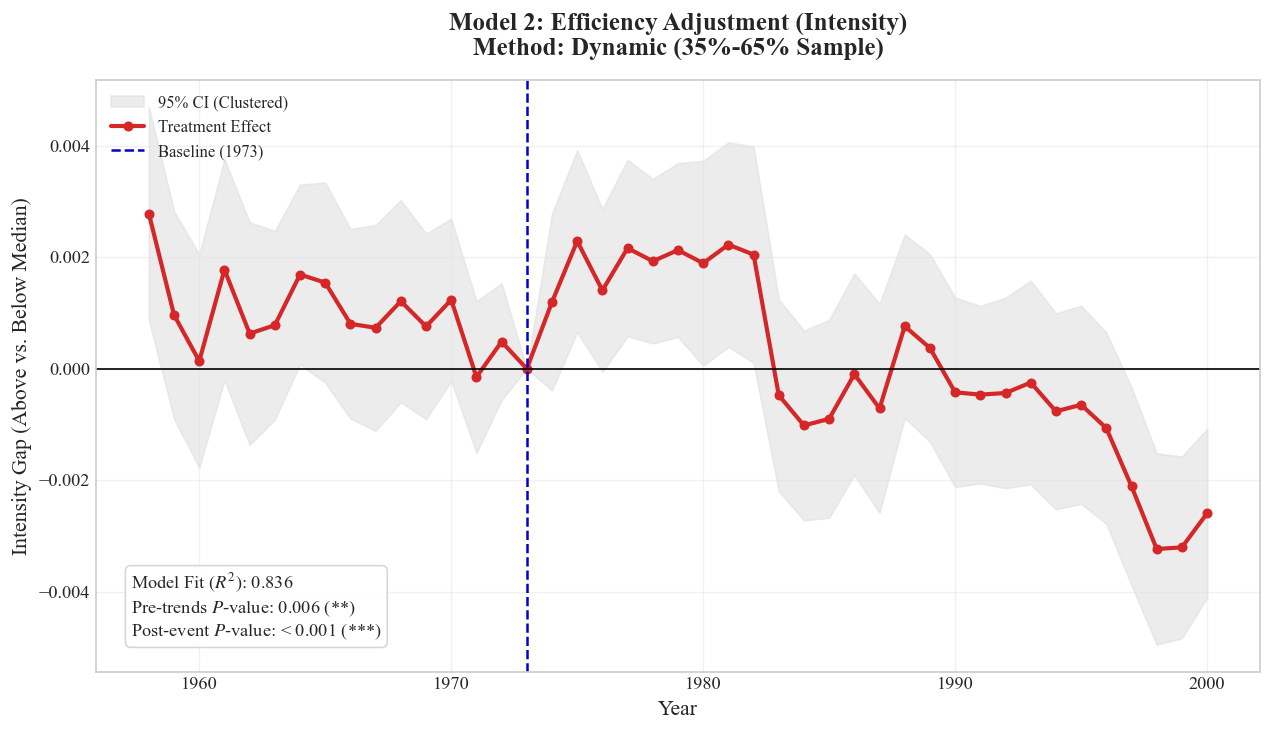

--- נתונים עבור טבלה 2 (מודל 2) ---
Observations (N): 4683
log_emp Coefficient: -0.0003
log_emp Standard Error: 0.0005
R-squared: 0.836
Pre-1973 F-test P-val: 0.0062
Post-1973 F-test P-val: 0.0000


In [69]:
# 1. סינון והכנת הנתונים מתוך טבלת החציון (35%-65%)
df_reg = regression_data_median.dropna(subset=['real_energy_intensity', 'treatment_above_median', 'log_emp', 'naics', 'year']).copy()
df_reg = df_reg[df_reg['year'] <= 2000]

# 2. הגדרת נוסחת הרגרסיה 
# שימוש ב-1973 כשנת הבסיס (Reference Year) מבטיח שהגרף יתאפס בדיוק בשנת המשבר
formula = "real_energy_intensity ~ treatment_above_median * C(year, Treatment(reference=1973)) + log_emp + C(naics)"

# הרצת המודל עם טעויות תקן מקובצות
model = smf.ols(formula, data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['naics']})
r2 = model.rsquared

interaction_prefix = "treatment_above_median:C(year, Treatment(reference=1973))"

# 3. חישוב מבחני F לתקופות טרום ופוסט משבר
pre_years = [y for y in df_reg['year'].unique() if y < 1973]
pre_terms = [f"{interaction_prefix}[T.{y}] = 0" for y in pre_years if f"{interaction_prefix}[T.{y}]" in model.params.index]
pre_pval = model.f_test(", ".join(pre_terms)).pvalue if pre_terms else 1.0

post_years = [y for y in range(1974, 2001)]
post_terms = [f"{interaction_prefix}[T.{y}] = 0" for y in post_years if f"{interaction_prefix}[T.{y}]" in model.params.index]
post_pval = model.f_test(", ".join(post_terms)).pvalue if post_terms else 1.0

# 4. חילוץ המקדמים לציור הגרף
years, coefs, lower, upper = [1973], [0], [0], [0] # 1973 היא שנת הבסיס

for param in model.params.index:
    if interaction_prefix in param:
        try:
            y_int = int(param.split("[T.")[1].split("]")[0])
            years.append(y_int)
            coefs.append(model.params[param])
            ci = model.conf_int().loc[param]
            lower.append(ci[0])
            upper.append(ci[1])
        except:
            continue

plot_df = pd.DataFrame({'Year': years, 'Coef': coefs, 'Lower': lower, 'Upper': upper}).sort_values('Year')

# 5. יצירת הגרף (בסגנון אקדמי נקי כמו בתמונה)
# הגדרת פונט סריפי למראה אקדמי
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(11, 6.5))

# אזור רווח הסמך (Confidence Interval)
ax.fill_between(plot_df['Year'], plot_df['Lower'], plot_df['Upper'], color='#e0e0e0', alpha=0.6, label='95% CI (Clustered)')

# קו המגמה
ax.plot(plot_df['Year'], plot_df['Coef'], color='#d62728', linewidth=2.5, marker='o', markersize=5, label='Treatment Effect')

# קווי ייחוס (אפס וזמן משבר)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(1973, color='mediumblue', linestyle='--', linewidth=1.5, label='Baseline (1973)')

# קוביית הנתונים הסטטיסטיים
def format_p(p):
    if p < 0.001: return "< 0.001 (***)"
    if p < 0.05: return f"{p:.3f} (**)"
    return f"{p:.3f} (NS)"

stats_text = (
    f"Model Fit ($R^2$): {r2:.3f}\n"
    f"Pre-trends $P$-value: {format_p(pre_pval)}\n"
    f"Post-event $P$-value: {format_p(post_pval)}"
)

ax.text(0.03, 0.05, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray'))

# עיצוב כללי
ax.set_title("Model 2: Efficiency Adjustment (Intensity)\nMethod: Dynamic (35%-65% Sample)", fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel("Intensity Gap (Above vs. Below Median)", fontsize=13)
ax.set_xlabel("Year", fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, color='lightgray', linestyle='-')
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.show()
# חילוץ והדפסת הנתונים עבור טבלה 2 (מודל עצימות האנרגיה)
print("--- נתונים עבור טבלה 2 (מודל 2) ---")
print(f"Observations (N): {int(model.nobs)}")
print(f"log_emp Coefficient: {model.params['log_emp']:.4f}")
print(f"log_emp Standard Error: {model.bse['log_emp']:.4f}")
print(f"R-squared: {model.rsquared:.3f}")
print(f"Pre-1973 F-test P-val: {pre_pval:.4f}")
print(f"Post-1973 F-test P-val: {post_pval:.4f}")

In [68]:
# הגדרת המודלים שאנחנו רוצים להריץ
models_to_run = [
    {'name': 'Model 1: TFP (Productivity)', 'dep_var': 'tfp5'},
    {'name': 'Model 2: Energy Intensity', 'dep_var': 'real_energy_intensity'},
    {'name': 'Model 3: Cumulative Growth (Log VADD)', 'dep_var': 'log_vadd'}
]

output_file = "Clean_Dynamic_Regression_Tables.txt"

with open(output_file, 'w', encoding='utf-8') as f:
    f.write("=== SUMMARY OF DYNAMIC EVENT STUDY REGRESSIONS ===\n")
    f.write("Note: Industry (NAICS) and Year Fixed Effects are included but hidden for clarity.\n\n")
    
    for m in models_to_run:
        dep_var = m['dep_var']
        f.write(f"==============================================================\n")
        f.write(f" {m['name']} \n")
        f.write(f"==============================================================\n")
        
        # *** השימוש ב-df_1999 הקיים שלך ***
        df_model = df_1999.dropna(subset=[dep_var, 'log_emp']).copy()
        
        # נוסחת המודל הדינמי
        formula = f"{dep_var} ~ is_high_energy * C(year, Treatment(reference=1972)) + log_emp + C(naics)"
        
        try:
            # הרצת הרגרסיה עם טעויות תקן רובסטיות
            model = smf.ols(formula, data=df_model).fit(cov_type='HC3')
            
            # חישוב מבחן F-test לשנים שלאחר המשבר (1974-1999)
            post_years = list(range(1974, 2000)) # רץ עד 1999 כולל
            f_test_terms = [f"is_high_energy:C(year, Treatment(reference=1972))[T.{y}] = 0" for y in post_years if f"is_high_energy:C(year, Treatment(reference=1972))[T.{y}]" in model.params.index]
            
            if f_test_terms:
                f_pval = model.f_test(", ".join(f_test_terms)).pvalue
            else:
                f_pval = 1.0
                
            # עיצוב כוכבי מובהקות ל-F-test
            if f_pval < 0.001:
                p_text = "< 0.001 (***)"
            elif f_pval < 0.01:
                p_text = f"{f_pval:.4f} (***)"
            elif f_pval < 0.05:
                p_text = f"{f_pval:.4f} (**)"
            elif f_pval < 0.1:
                p_text = f"{f_pval:.4f} (*)"
            else:
                p_text = f"{f_pval:.4f}"

            # הדפסת הנתונים הכלליים של המודל
            f.write(f"Observations (N)       : {int(model.nobs):,}\n")
            f.write(f"R-squared              : {model.rsquared:.3f}\n")
            f.write(f"Post-1973 F-test P-val : {p_text}\n")
            f.write(f"Industry Fixed Effects : Yes\n")
            f.write(f"Year Fixed Effects     : Yes\n\n")
            
            # כותרות לעמודות
            f.write(f"{'Variable':<30} | {'Coef':<10} | {'Std.Err':<10} | {'P-value':<10}\n")
            f.write("-" * 68 + "\n")
            
            # הדפסת משתנה הבקרה
            if 'log_emp' in model.params:
                coef = model.params['log_emp']
                se = model.bse['log_emp']
                pval = model.pvalues['log_emp']
                f.write(f"{'log_emp (Industry Size)':<30} | {coef:>10.4f} | {se:>10.4f} | {pval:>10.4f}\n")
            
            f.write("-" * 68 + "\n")
            f.write("Dynamic Interaction Terms (is_high_energy * Year):\n")
            
            # הדפסת המקדמים השנתיים (מ-1958 ועד 1999 כולל)
            for y in range(1958, 2000):
                term = f"is_high_energy:C(year, Treatment(reference=1972))[T.{y}]"
                if term in model.params:
                    coef = model.params[term]
                    se = model.bse[term]
                    pval = model.pvalues[term]
                    
                    # הוספת כוכביות למקדמים שנתיים בודדים
                    stars = ""
                    if pval < 0.01: stars = "***"
                    elif pval < 0.05: stars = "**"
                    elif pval < 0.1: stars = "*"
                    
                    display_name = f"HighEnergy x {y}"
                    f.write(f"{display_name:<30} | {coef:>10.4f} | {se:>10.4f} | {pval:>6.4f} {stars}\n")
            
        except Exception as e:
            f.write(f"Error running model: {e}\n")
            
        f.write("\n\n")

print(f"✅ הצלחנו! הנתונים הנקיים נשמרו לקובץ: '{output_file}'")

KeyboardInterrupt: 

In [74]:
import pandas as pd
import numpy as np

# 1. מוודאים שפונקציית ה-PSM כבר רצה והמאגר 'Dynamic' קיים
if 'matched_datasets' in locals() and 'Dynamic' in matched_datasets:
    
    # טוענים את מאגר הנתונים שכבר שודך וסונן על ידי הפונקציה שלך
    df_dyn = matched_datasets['Dynamic'].copy()
    
    # 2. חישוב סטטיסטיקות כלליות על סמך מה שהפונקציה שלך השאירה
    total_obs = len(df_dyn)
    total_unique_industries = df_dyn['naics'].nunique()
    
    # חישוב ממוצע זוגות משודכים לשנה (כל חברה מטופלת משודכת לאחת מהביקורת, לכן חלקי 2)
    avg_pairs_per_year = (df_dyn.groupby('year').size() / 2).mean()
    
    # 3. פיצול לקבוצות טיפול וביקורת לפי המשתנה המקורי
    treated = df_dyn[df_dyn['is_high_energy'] == 1]
    control = df_dyn[df_dyn['is_high_energy'] == 0]
    
    # 4. הכנת טקסט הנספח באנגלית
    output_text = (
        "=== GENERAL SUMMARY: DYNAMIC PSM MATCHED SAMPLE ===\n"
        "========================================================================\n"
        f"Total Matched Observations (N) : {total_obs:,}\n"
        f"Total Unique Industries        : {total_unique_industries:,}\n"
        f"Average Matched Pairs per Year : {avg_pairs_per_year:.1f} pairs\n"
        "------------------------------------------------------------------------\n"
        f"Treatment Group (High Energy)  : {len(treated):,} observations | {treated['naics'].nunique():,} unique industries\n"
        f"Control Group   (Low Energy)   : {len(control):,} observations | {control['naics'].nunique():,} unique industries\n"
        "========================================================================\n"
        "Methodological Note:\n"
        "This sample represents the output of a dynamic Propensity Score Matching (PSM) \n"
        "algorithm applied iteratively year-by-year. \n\n"
        "Matching Parameters used:\n"
        " - Covariates: log_emp, log_real_vadd, log_cap\n"
        " - Algorithm: Nearest Neighbor (k=1) with Logistic Regression propensity scores.\n"
        " - Caliper: 0.05 (industries without a close match were dropped to ensure quality).\n\n"
        "The resulting dataset ensures a highly balanced comparison between energy-intensive \n"
        "and non-intensive industries, adapting to structural changes over the study period."
    )
    
    # 5. הדפסה למסך ושמירה לקובץ
    print(output_text)
    
    with open("Dynamic_PSM_Existing_Function_Summary.txt", "w", encoding='utf-8') as f:
        f.write(output_text)
        
    print("\n✅ המלל נוצר בהצלחה מתוך הפונקציה המקורית ונשמר כ- 'Dynamic_PSM_Existing_Function_Summary.txt'")

else:
    print("❌ שגיאה: לא מצאתי את 'matched_datasets['Dynamic']'. ודא שהרצת את תא ה-PSM לפני כן.")

=== GENERAL SUMMARY: DYNAMIC PSM MATCHED SAMPLE ===
Total Matched Observations (N) : 9,178
Total Unique Industries        : 338
Average Matched Pairs per Year : 109.3 pairs
------------------------------------------------------------------------
Treatment Group (High Energy)  : 4,589 observations | 123 unique industries
Control Group   (Low Energy)   : 4,589 observations | 215 unique industries
Methodological Note:
This sample represents the output of a dynamic Propensity Score Matching (PSM) 
algorithm applied iteratively year-by-year. 

Matching Parameters used:
 - Covariates: log_emp, log_real_vadd, log_cap
 - Algorithm: Nearest Neighbor (k=1) with Logistic Regression propensity scores.
 - Caliper: 0.05 (industries without a close match were dropped to ensure quality).

The resulting dataset ensures a highly balanced comparison between energy-intensive 
and non-intensive industries, adapting to structural changes over the study period.

✅ המלל נוצר בהצלחה מתוך הפונקציה המקורית ונשמר